In [ ]:
!pip install numpy matplotlib scipy h5py


In [ ]:
!pip install gurobipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 72.0 MB/s eta 0:00:00


Variables in file: ['ori_data']
Data shape loaded: (48, 954, 210)


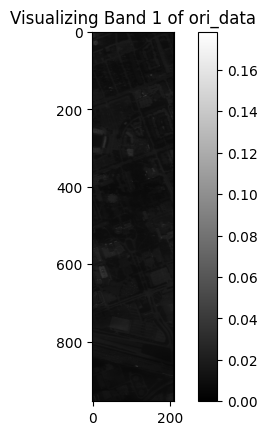

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# 1. Open the v7.3 .mat file
with h5py.File("Houston13.mat", "r") as f:
    # 2. Print all variables inside the file to find your dataset name
    print("Variables in file:", list(f.keys()))

    # 3. Load the dataset (Replace 'Houston' if your variable name is different)
    # common variable names for this dataset are 'Houston' or 'inst'
    data_variable = list(f.keys())[0]  # Automatically grabs the first variable
    data = np.array(f[data_variable])

# 4. Fix MATLAB vs Python axis ordering
# MATLAB v7.3 stores arrays transposed: (Bands, Width, Height) or (Bands, Height, Width)
print("Data shape loaded:", data.shape)

# 5. Visualize a single slice/band of the dataset
if data.ndim == 3:
    # Hyperspectral data is 3D. Let's look at the first band/slice.
    # If the shape looks like (Bands, Height, Width), we slice the first dimension:
    plt.imshow(data[0, :, :], cmap="gray")
    plt.title(f"Visualizing Band 1 of {data_variable}")
    plt.colorbar()
    plt.show()
elif data.ndim == 2:
    # If it is a 2D image or ground truth map:
    plt.imshow(data, cmap="jet")
    plt.colorbar()
    plt.show()


Successfully loaded shape: (48, 954, 210)


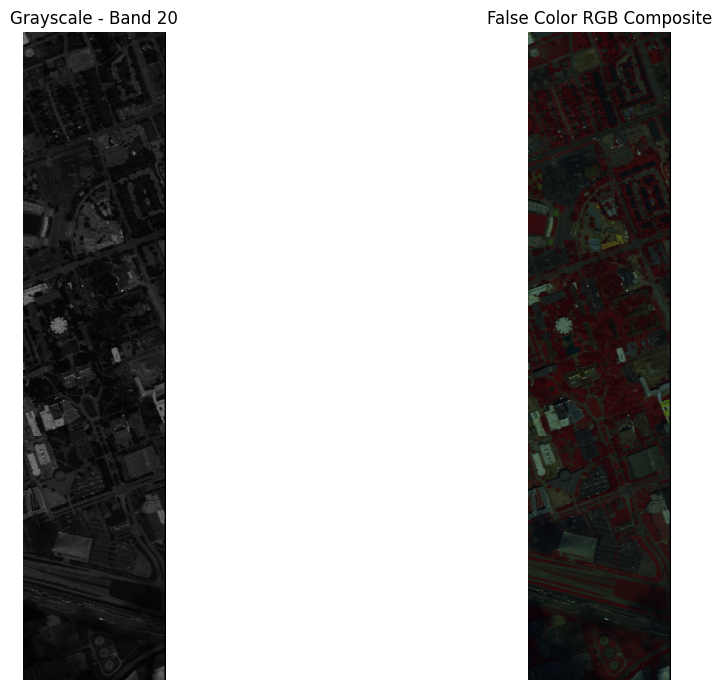

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data
with h5py.File("Houston13.mat", "r") as f:
    # f['ori_data'] is loaded as (Bands, Height, Width)
    data = np.array(f["ori_data"])

print("Successfully loaded shape:", data.shape)

# Create a window with two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# --- PLOT 1: Single Band Grayscale ---
# We pick Band index 20 out of the 48 available bands
band_to_view = 20
axes[0].imshow(data[band_to_view, :, :], cmap="gray")
axes[0].set_title(f"Grayscale - Band {band_to_view}")
axes[0].axis("off")

# --- PLOT 2: False Color RGB ---
# Choose 3 distinct bands to represent Red, Green, and Blue.
# Since you have 48 bands, let's pick spread-out bands like 35, 20, and 5.
r_band = data[35, :, :]
g_band = data[20, :, :]
b_band = data[5, :, :]

# Stack them along the last axis to make a standard (Height, Width, 3) RGB image
rgb_image = np.stack([r_band, g_band, b_band], axis=-1)

# Normalize the data between 0 and 1 so matplotlib can display it correctly
rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

axes[1].imshow(rgb_image)
axes[1].set_title("False Color RGB Composite")
axes[1].axis("off")

plt.tight_layout()
plt.show()


Dataset contains 200340 unique pixels, each with 48 spectral bands.


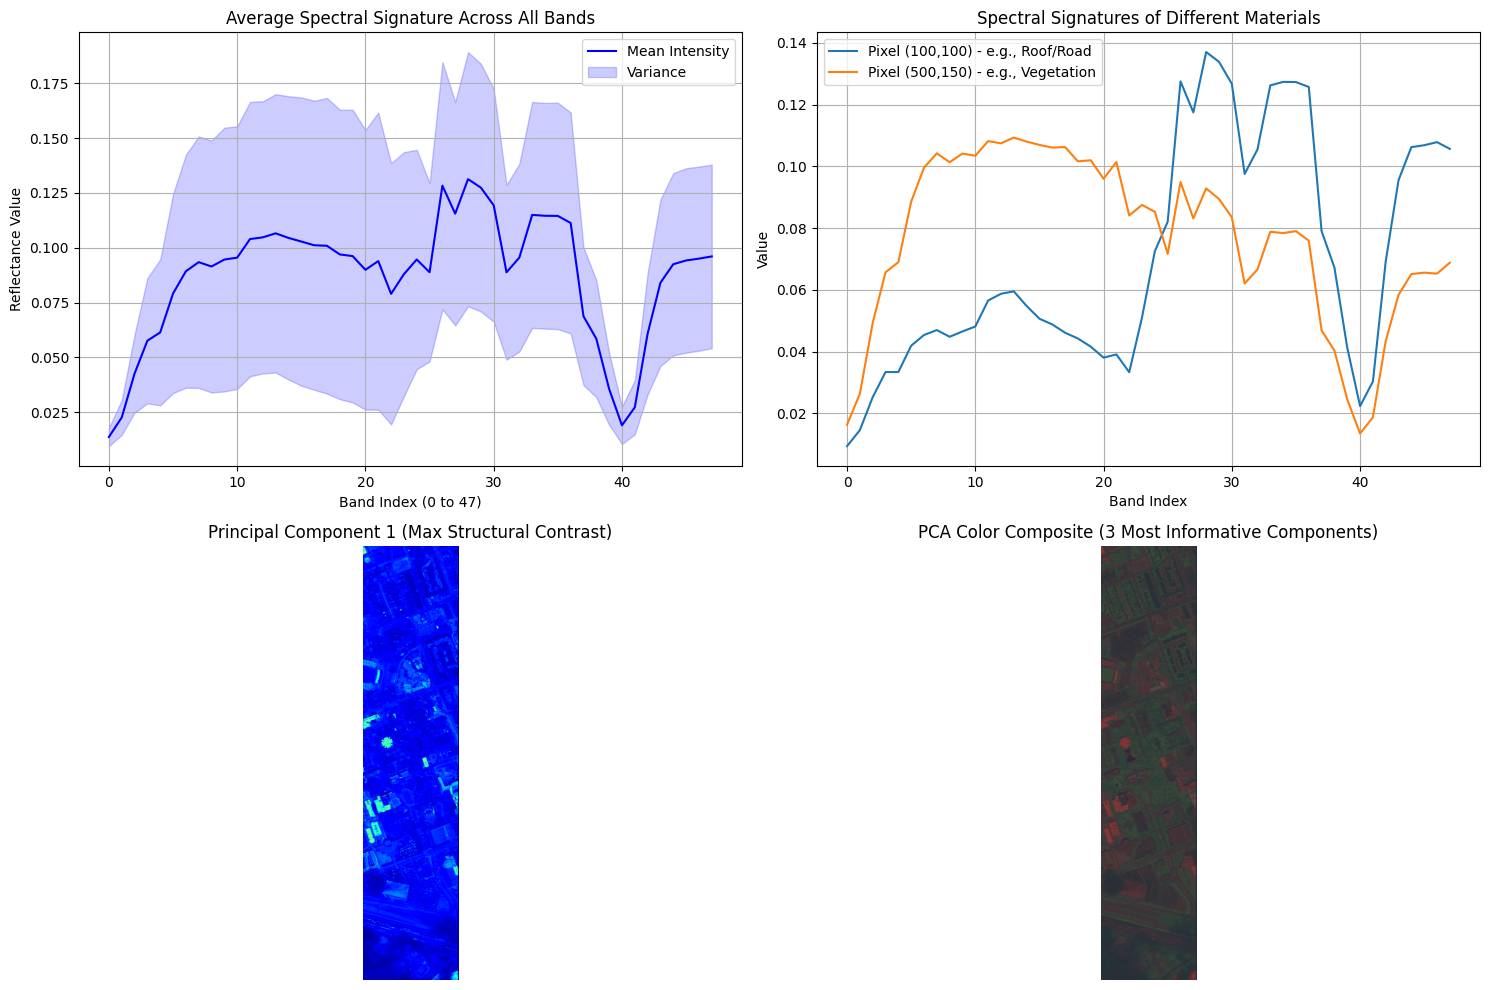

The first 3 PCA components explain 99.38% of the total data variance!


In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# 1. Load Data
with h5py.File("Houston13.mat", "r") as f:
    data = np.array(f["ori_data"])  # Shape: (48, 954, 210)

# Reshape data for pixel-based analysis: (954 * 210, 48) -> (200340 pixels, 48 bands)
bands, height, width = data.shape
pixels = data.reshape(bands, height * width).T

print(f"Dataset contains {pixels.shape[0]} unique pixels, each with 48 spectral bands.")

# --- ANALYSIS 1: Overall Dataset Statistics ---
mean_spectrum = np.mean(pixels, axis=0)
std_spectrum = np.std(pixels, axis=0)

# --- ANALYSIS 2: PCA (Principal Component Analysis) ---
# Compresses 48 bands into the 3 most informative visual channels
pca = PCA(n_components=3)
pca_pixels = pca.fit_transform(pixels)
pca_image = pca_pixels.reshape(height, width, 3)

# Normalize PCA image for visualization
pca_image = (pca_image - pca_image.min()) / (pca_image.max() - pca_image.min())

# --- PLOTTING THE RESULTS ---
fig = plt.figure(figsize=(15, 10))

# Plot A: Mean Spectral Curve (The dataset's average light reflection profile)
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(mean_spectrum, color="blue", label="Mean Intensity")
ax1.fill_between(
    range(bands),
    mean_spectrum - std_spectrum,
    mean_spectrum + std_spectrum,
    alpha=0.2,
    color="blue",
    label="Variance",
)
ax1.set_title("Average Spectral Signature Across All Bands")
ax1.set_xlabel("Band Index (0 to 47)")
ax1.set_ylabel("Reflectance Value")
ax1.legend()
ax1.grid(True)

# Plot B: Spectral Signatures of Specific Target Pixels
# Picking sample coordinates: Center pixel, top-left, and bottom-right
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(data[:, 100, 100], label="Pixel (100,100) - e.g., Roof/Road")
ax2.plot(data[:, 500, 150], label="Pixel (500,150) - e.g., Vegetation")
ax2.set_title("Spectral Signatures of Different Materials")
ax2.set_xlabel("Band Index")
ax2.set_ylabel("Value")
ax2.legend()
ax2.grid(True)

# Plot C: PCA Component 1 (Captures the highest variance/contrast in the scene)
ax3 = fig.add_subplot(2, 2, 3)
first_pc = pca_pixels[:, 0].reshape(height, width)
ax3.imshow(first_pc, cmap="jet")
ax3.set_title("Principal Component 1 (Max Structural Contrast)")
ax3.axis("off")

# Plot D: PCA False Color Composite
ax4 = fig.add_subplot(2, 2, 4)
ax4.imshow(pca_image)
ax4.set_title("PCA Color Composite (3 Most Informative Components)")
ax4.axis("off")

plt.tight_layout()
plt.show()

# Print Explained Variance
print(
    f"The first 3 PCA components explain {np.sum(pca.explained_variance_ratio_)*100:.2f}% of the total data variance!"
)


In [ ]:
import h5py
import numpy as np

# 1. Open the Ground Truth and Data Files
with h5py.File("/content/Houston13.mat", "r") as f_data, h5py.File(
    "/content/Houston13_7gt.mat", "r"
) as f_gt:

    # Extract arrays
    data = np.array(f_data["ori_data"])  # Data Cube
    gt_map = np.array(f_gt["map"])  # Ground Truth Map

print("=== DATASET STRUCTURE ===")
print(f"Data Cube Shape: {data.shape} -> (Bands, Height, Width)")
print(f"Ground Truth Shape: {gt_map.shape} -> (Height, Width)")

# 2. Count Labeled Pixels
unique_classes, pixel_counts = np.unique(gt_map, return_counts=True)

print("\n=== LABELS AND CLASS DISTRIBUTION ===")
print(f"Total Unique Class IDs found: {len(unique_classes)}")

# Class 0 represents background / unlabeled pixels
for class_id, count in zip(unique_classes, pixel_counts):
    if class_id == 0:
        print(f"Class 0 (Background / Unlabeled): {count} pixels")
    else:
        print(f"Class {int(class_id)}: {count} labeled pixels")


=== DATASET STRUCTURE ===
Data Cube Shape: (48, 954, 210) -> (Bands, Height, Width)
Ground Truth Shape: (954, 210) -> (Height, Width)

=== LABELS AND CLASS DISTRIBUTION ===
Total Unique Class IDs found: 8
Class 0 (Background / Unlabeled): 197810 pixels
Class 1: 345 labeled pixels
Class 2: 365 labeled pixels
Class 3: 365 labeled pixels
Class 4: 285 labeled pixels
Class 5: 319 labeled pixels
Class 6: 408 labeled pixels
Class 7: 443 labeled pixels


In [ ]:
data.shape

(48, 954, 210)

/tmp/ipykernel_1500/1794851728.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 8)  # 8 bins for classes 0 through 7


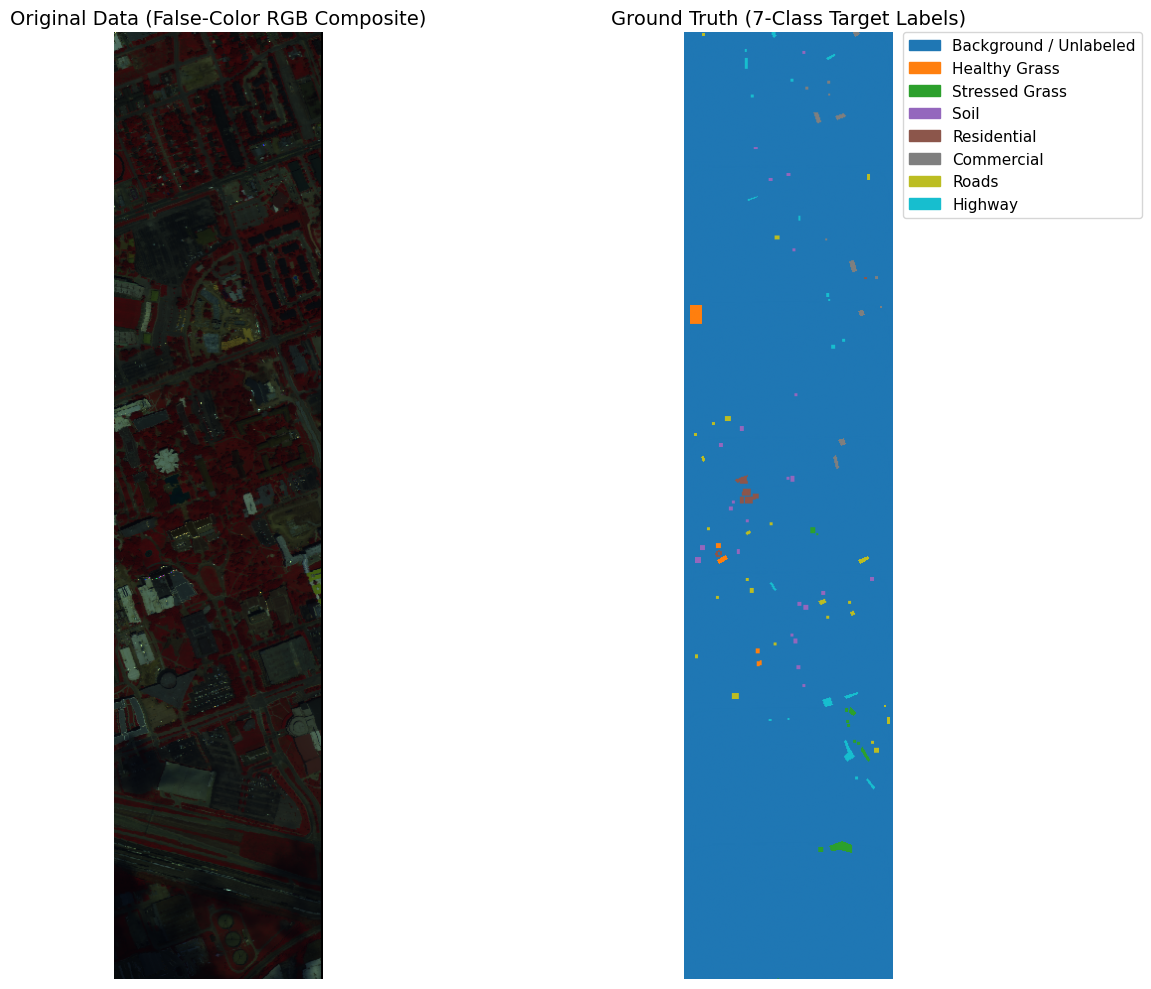

In [ ]:
import h5py
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Data Cube and Ground Truth Map from /content/
with h5py.File("/content/Houston13.mat", "r") as f_data, h5py.File(
    "/content/Houston13_7gt.mat", "r"
) as f_gt:
    data = np.array(f_data["ori_data"])  # Shape: (48, 954, 210)
    gt_map = np.array(f_gt["map"])  # Shape: (954, 210)

# 2. Generate a False-Color RGB image from the Data Cube
# We pick three spread-out bands to map to Red, Green, and Blue channels
r_band = data[35, :, :]
g_band = data[20, :, :]
b_band = data[5, :, :]
rgb_image = np.stack([r_band, g_band, b_band], axis=-1)

# Normalize RGB values between 0 and 1 for matplotlib display
rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

# 3. Create the Side-by-Side Plot Layout
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# --- PLOT 1: Dataset RGB Composite ---
axes[0].imshow(rgb_image)
axes[0].set_title("Original Data (False-Color RGB Composite)", fontsize=14)
axes[0].axis("off")

# --- PLOT 2: Ground Truth Classification Map ---
# 'jet' or 'tab10' are great distinct colormaps for category masks
cmap = plt.cm.get_cmap("tab10", 8)  # 8 bins for classes 0 through 7
im = axes[1].imshow(gt_map, cmap=cmap)
axes[1].set_title("Ground Truth (7-Class Target Labels)", fontsize=14)
axes[1].axis("off")

# --- 4. Add a Custom Legend for the Classes ---
# Standard names for the 7-class Houston configuration
class_names = {
    0: "Background / Unlabeled",
    1: "Healthy Grass",
    2: "Stressed Grass",
    3: "Soil",
    4: "Residential",
    5: "Commercial",
    6: "Roads",
    7: "Highway",
}

# Create matching colored boxes for the legend
colors = [cmap(i) for i in range(8)]
legend_patches = [
    mpatches.Patch(color=colors[i], label=class_names[i]) for i in range(8)
]

# Put the legend on the right side of the layout
axes[1].legend(
    handles=legend_patches,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=11,
    borderaxespad=0.0,
)

plt.tight_layout()
plt.show()


In [4]:
!pip install hdf5storage cleanlab gurobipy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 75.9 MB/s eta 0:00:00


1.0 0.0
1.0 0.0
#######################idataset########################  0
get_sample_data() run...
The original sample data shape: (954, 210, 48)
num_class : 7
the number of val data: 2180
the number of processed data: 350
sample data shape (350, 48, 7, 7)
sample label shape (350,)
get_sample_data() end...
get_all_data() run...
The original data shape: (954, 210, 48)
num_class : 7
the number of all data: 53200
processed all data shape: (53200, 48, 7, 7)
processed all label shape: (53200,)
get_all_data() end...
Training...
learning rate 0.0500
epoch   1:   cls loss: 1.9372,lmmd loss:2.020632, occ loss:1.137526 ,fft_cls_loss:1.960604 ,acc 0.1562, total loss: 3.0747
learning rate 0.0500
epoch   2:   cls loss: 1.6612,lmmd loss:1.599082, occ loss:0.402719 ,fft_cls_loss:1.857646 ,acc 0.1641, total loss: 2.0639
learning rate 0.0500
epoch   3:   cls loss: 1.4176,lmmd loss:1.539073, occ loss:0.246118 ,fft_cls_loss:1.706395 ,acc 0.2682, total loss: 1.6637
learning rate 0.0500
epoch   4:   cls l

0

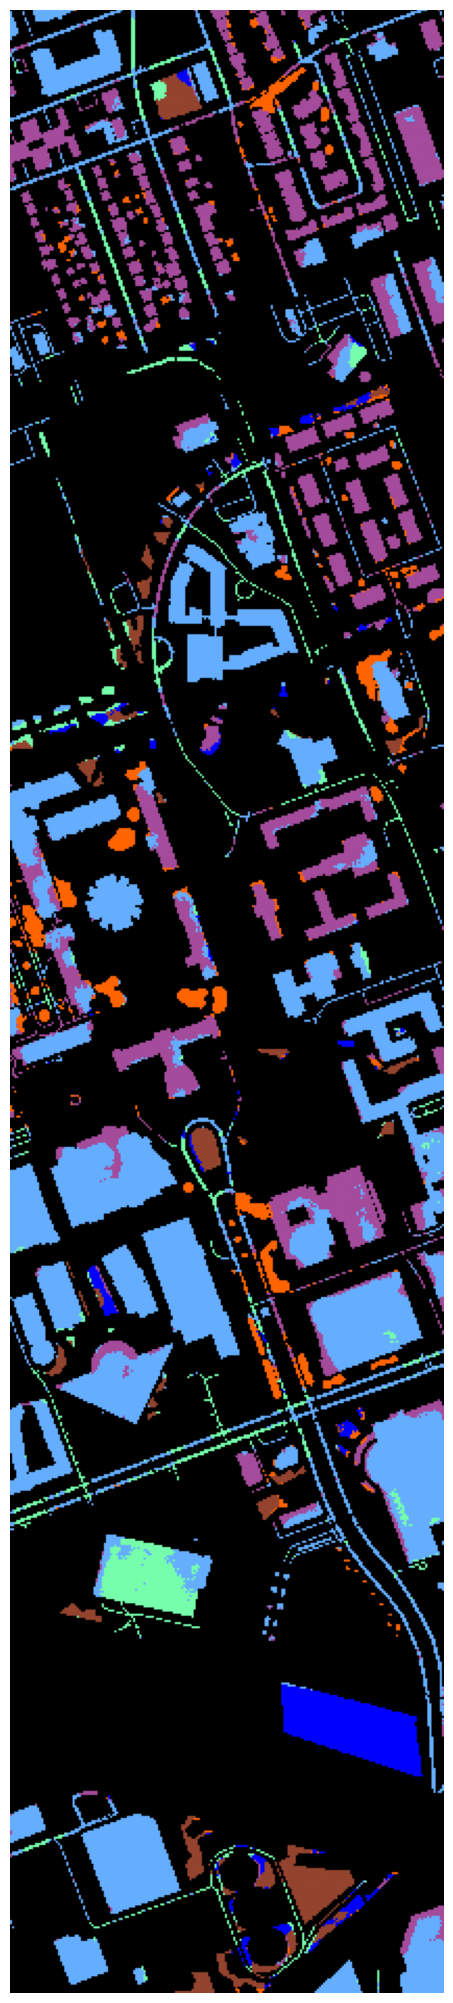

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import functools
import numpy as np


def calc_ins_mean_std(x, eps=1e-5):
    """extract feature map statistics"""
    # eps is a small value added to the variance to avoid divide-by-zero.
    size = x.size()
    assert (len(size) == 4)
    N, C = size[:2]
    var = x.contiguous().view(N, C, -1).var(dim=2) + eps
    std = var.sqrt().view(N, C, 1, 1)
    mean = x.contiguous().view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
    return mean, std


def instance_norm_mix(content_feat, style_feat):
    """replace content statistics with style statistics"""
    assert (content_feat.size()[:2] == style_feat.size()[:2])
    size = content_feat.size()
    style_mean, style_std = calc_ins_mean_std(style_feat)
    content_mean, content_std = calc_ins_mean_std(content_feat)

    normalized_feat = (content_feat - content_mean.expand(
        size)) / content_std.expand(size)
    return normalized_feat * style_std.expand(size) + style_mean.expand(size)


def cn_rand_bbox(size, beta, bbx_thres):
    """sample a bounding box for cropping."""
    W = size[2]
    H = size[3]
    while True:
        ratio = np.random.beta(beta, beta)
        cut_rat = np.sqrt(ratio)
        cut_w = np.int(W * cut_rat)
        cut_h = np.int(H * cut_rat)

        # uniform
        cx = np.random.randint(W)
        cy = np.random.randint(H)

        bbx1 = np.clip(cx - cut_w // 2, 0, W)
        bby1 = np.clip(cy - cut_h // 2, 0, H)
        bbx2 = np.clip(cx + cut_w // 2, 0, W)
        bby2 = np.clip(cy + cut_h // 2, 0, H)

        ratio = float(bbx2 - bbx1) * (bby2 - bby1) / (W * H)
        if ratio > bbx_thres:
            break

    return bbx1, bby1, bbx2, bby2


def cn_op_2ins_space_chan(x, crop='neither', beta=1, bbx_thres=0.1, lam=None, chan=False):
    """2-instance crossnorm with cropping."""

    assert crop in ['neither', 'style', 'content', 'both']
    ins_idxs = torch.randperm(x.size()[0]).to(x.device)

    if crop in ['style', 'both']:
        bbx3, bby3, bbx4, bby4 = cn_rand_bbox(x.size(), beta=beta, bbx_thres=bbx_thres)
        x2 = x[ins_idxs, :, bbx3:bbx4, bby3:bby4]
    else:
        x2 = x[ins_idxs]

    if chan:
        chan_idxs = torch.randperm(x.size()[1]).to(x.device)
        x2 = x2[:, chan_idxs, :, :]

    if crop in ['content', 'both']:
        x_aug = torch.zeros_like(x)
        bbx1, bby1, bbx2, bby2 = cn_rand_bbox(x.size(), beta=beta, bbx_thres=bbx_thres)
        x_aug[:, :, bbx1:bbx2, bby1:bby2] = instance_norm_mix(content_feat=x[:, :, bbx1:bbx2, bby1:bby2],
                                                              style_feat=x2)

        mask = torch.ones_like(x, requires_grad=False)
        mask[:, :, bbx1:bbx2, bby1:bby2] = 0.
        x_aug = x * mask + x_aug
    else:
        x_aug = instance_norm_mix(content_feat=x, style_feat=x2)

    if lam is not None:
        x = x * lam + x_aug * (1-lam)
    else:
        x = x_aug

    return x


class CrossNorm(nn.Module):
    """CrossNorm module"""
    def __init__(self, crop=None, beta=None):
        super(CrossNorm, self).__init__()

        self.active = False
        self.cn_op = functools.partial(cn_op_2ins_space_chan,
                                       crop=crop, beta=beta)

    def forward(self, x):
        if self.training and self.active:

            x = self.cn_op(x)

        self.active = False

        return x


class SelfNorm(nn.Module):
    """SelfNorm module"""
    def __init__(self, chan_num, is_two=False):
        super(SelfNorm, self).__init__()

        # channel-wise fully connected layer
        self.g_fc = nn.Conv1d(chan_num, chan_num, kernel_size=2,
                              bias=False, groups=chan_num)
        self.g_bn = nn.BatchNorm1d(chan_num)

        if is_two is True:
            self.f_fc = nn.Conv1d(chan_num, chan_num, kernel_size=2,
                                  bias=False, groups=chan_num)
            self.f_bn = nn.BatchNorm1d(chan_num)
        else:
            self.f_fc = None

    def forward(self, x):
        b, c, _, _ = x.size()

        mean, std = calc_ins_mean_std(x, eps=1e-12)

        statistics = torch.cat((mean.squeeze(3), std.squeeze(3)), -1)

        g_y = self.g_fc(statistics)
        g_y = self.g_bn(g_y)
        g_y = torch.sigmoid(g_y)
        g_y = g_y.view(b, c, 1, 1)

        if self.f_fc is not None:
            f_y = self.f_fc(statistics)
            f_y = self.f_bn(f_y)
            f_y = torch.sigmoid(f_y)
            f_y = f_y.view(b, c, 1, 1)

            return x * g_y.expand_as(x) + mean.expand_as(x) * (f_y.expand_as(x)-g_y.expand_as(x))
        else:
            return x * g_y.expand_as(x)

class CNSN(nn.Module):
    """A module to combine CrossNorm and SelfNorm"""
    def __init__(self, crossnorm, selfnorm):
        super(CNSN, self).__init__()
        self.crossnorm = crossnorm
        self.selfnorm = selfnorm

    def forward(self, x):
        if self.crossnorm and self.crossnorm.active:
            x = self.crossnorm(x)
        if self.selfnorm:
            x = self.selfnorm(x)
        return x

import torch
import torch.nn as nn
import torch.nn.functional as F

# SelfNorm = SelfNorm(num_class)
# CrossNorm = CrossNorm()

class DSAN(nn.Module):
    def __init__(self, n_band=198, patch_size=3,num_class=3):
        super(DSAN, self).__init__()
        self.alpha = nn.Parameter(torch.tensor(0.5), requires_grad=True).to(0)
        self.SelfNorm = SelfNorm(n_band)
        self.CrossNorm = CrossNorm()
        self.n_outputs = 288
        self.num_class = num_class
        self.feature_layers = DCRN_02(n_band,patch_size,num_class)

        self.fc1 = nn.Linear(288, num_class)
        self.fc2 = nn.Linear(288, 1)

        self.head1 = nn.Sequential(
            nn.Linear(288, 128),
            # nn.ReLU(inplace=True),
            # nn.Linear(288, 128)
        )
        self.head2 = nn.Sequential(
            nn.Linear(288, 128),
            # nn.ReLU(inplace=True),
            # nn.Linear(288, 128)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        f1 = x
        # FFT = self.feature_layersFFT(x)
        # pfft = self.fcfft(FFT)
        f2 = self.CrossNorm(x)
        f2 = self.SelfNorm(f2)
        x = self.alpha * f1 + (1-self.alpha) * f2
        features = self.feature_layers(x)
        # x1 = F.normalize(self.head1(features), dim=1)
        # x2 = F.normalize(self.head2(features), dim=1)

        fea = self.fc1(features)
        output = self.fc2(features)
        output = self.sigmoid(output)

        return features, features, features, fea, output


# class DSANJ(nn.Module):
#     def __init__(self, n_band=198, patch_size=3,num_class=3):
#         super(DSANJ, self).__init__()
#         self.n_outputs = 288
#         self.feature_layers = DCRN_02(n_band,patch_size,num_class)
#         self.C = nn.Linear(128, num_class)
#         self.C1 = nn.Linear(128, num_class)
#         self.C2 = nn.Linear(128, num_class)
#         self.fc2 = nn.Linear(288, 1)
#
#         self.head1 = nn.Sequential(
#             nn.Linear(288, 128),
#             # nn.ReLU(inplace=True),
#             # nn.Linear(288, 128)
#         )
#         self.head2 = nn.Sequential(
#             nn.Linear(288, 128),
#             # nn.ReLU(inplace=True),
#             # nn.Linear(288, 128)
#         )
#         self.head = nn.Sequential(
#             nn.Linear(288, 128),
#             # nn.ReLU(inplace=True),
#             # nn.Linear(288, 128)
#         )
#         self.sigmoid = nn.Sigmoid()
#
#     def forward(self,x):
#         features = self.feature_layers(x)
#
#         # x1 = F.normalize(self.head1(features), dim=1)
#         # x2 = F.normalize(self.head2(features), dim=1)
#         x = F.normalize(self.head(features), dim=1)
#
#
#         # C1 = self.C1(x1)
#         # C2 = self.C2(x2)
#         C = self.C(x)
#         output = self.fc2(features)
#         output = self.sigmoid(output)
#
#         return features,C, output

    def get_embedding(self, x):
        out, _, _, _, _ = self.forward(x)
        return out

class DSAN1(nn.Module):
    def __init__(self, n_band=198, patch_size=3,num_class=3):
        super(DSAN1, self).__init__()
        self.n_outputs = 288
        self.feature_layers = DCRN_02(n_band,patch_size,num_class)

        self.fc1 = nn.Linear(288, num_class)
        self.fc2 = nn.Linear(288, 1)

        self.head1 = nn.Sequential(
            nn.Linear(288, 64),
            # nn.ReLU(inplace=True),
            # nn.Linear(288, 128)
        )
        self.head2 = nn.Sequential(
            nn.Linear(288, 64),
            # nn.ReLU(inplace=True),
            # nn.Linear(288, 128)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        features = self.feature_layers(x)

        x1 = F.normalize(self.head1(features), dim=1)
        x2 = F.normalize(self.head2(features), dim=1)

        fea = self.fc1(features)
        output = self.fc2(features)
        output = self.sigmoid(output)

        return features,x1,x2,fea, output

    def get_embedding(self, x):
        out, _, _, _, _ = self.forward(x)
        return out

class DSAN2(nn.Module):
    def __init__(self, n_band=198, patch_size=3,num_class=3):
        super(DSAN1, self).__init__()
        self.n_outputs = 152
        self.feature_layers = DCRN(n_band,patch_size,num_class)

        self.fc1 = nn.Linear(self.n_outputs, num_class)
        self.fc2 = nn.Linear(self.n_outputs, 1)

        self.head1 = nn.Sequential(
            nn.Linear(self.n_outputs, 128),
            # nn.ReLU(inplace=True),
            # nn.Linear(288, 128)
        )
        self.head2 = nn.Sequential(
            nn.Linear(self.n_outputs, 128),
            # nn.ReLU(inplace=True),
            # nn.Linear(288, 128)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        features = self.feature_layers(x)

        x1 = F.normalize(self.head1(features), dim=1)
        x2 = F.normalize(self.head2(features), dim=1)

        fea = self.fc1(features)
        output = self.fc2(features)
        output = self.sigmoid(output)

        return features,x1,x2,fea, output

    def get_embedding(self, x):
        out, _, _, _, _ = self.forward(x)
        return out

class DCRN_02(nn.Module):

    def __init__(self, input_channels, patch_size, n_classes):
        super(DCRN_02, self).__init__()
        self.inter_size = 192 + 96
        # self.SelfNorm = SelfNorm(self.inter_size)
        # self.CrossNorm = CrossNorm()
        self.kernel_dim = 1
        self.feature_dim = input_channels
        self.sz = patch_size
        # Convolution Layer 1 kernel_size = (1, 1, 7), stride = (1, 1, 2), output channels = 24
        self.conv1 = nn.Conv3d(1, 24, kernel_size=(7, 1, 1), stride=(2, 1, 1), bias=True)
        self.bn1 = nn.BatchNorm3d(24)
        self.activation1 = nn.ReLU()

        # Residual block 1
        self.conv2 = nn.Conv3d(24, 24, kernel_size=(7, 1, 1), stride=1, padding=(3, 0, 0),
                               bias=True)  # padding_mode='replicate',
        self.bn2 = nn.BatchNorm3d(24)
        self.activation2 = nn.ReLU()
        self.conv3 = nn.Conv3d(24, 24, kernel_size=(7, 1, 1), stride=1, padding=(3, 0, 0),
                               bias=True)  # padding_mode='replicate',
        self.bn3 = nn.BatchNorm3d(24)
        self.activation3 = nn.ReLU()
        # Finish

        # Convolution Layer 2 kernel_size = (1, 1, (self.feature_dim - 6) // 2), output channels = 128
        self.conv4 = nn.Conv3d(24, 192, kernel_size=(((self.feature_dim - 7) // 2 + 1), 1, 1), bias=True)
        self.bn4 = nn.BatchNorm3d(192)
        self.activation4 = nn.ReLU()

        # Convolution layer for spatial information
        self.conv5 = nn.Conv3d(1, 24, (self.feature_dim, 1, 1))
        self.bn5 = nn.BatchNorm3d(24)
        self.activation5 = nn.ReLU()

        # Residual block 2
        self.conv6 = nn.Conv3d(24, 24, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1),
                               bias=True)  # padding_mode='replicate',
        self.bn6 = nn.BatchNorm3d(24)
        self.activation6 = nn.ReLU()
        self.conv7 = nn.Conv3d(24, 96, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1),
                               bias=True)  # padding_mode='replicate',
        self.bn7 = nn.BatchNorm3d(96)
        self.activation7 = nn.ReLU()
        self.conv8 = nn.Conv3d(24, 96, kernel_size=1)
        # Finish

        # Combination shape
        # self.inter_size = 128 + 24


        # Residual block 3
        self.conv9 = nn.Conv3d(self.inter_size, self.inter_size, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1),
                               bias=True)  # padding_mode='replicate',
        self.bn9 = nn.BatchNorm3d(self.inter_size)
        self.activation9 = nn.ReLU()
        self.conv10 = nn.Conv3d(self.inter_size, self.inter_size, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1),
                                bias=True)  # padding_mode='replicate',
        self.bn10 = nn.BatchNorm3d(self.inter_size)
        self.activation10 = nn.ReLU()

        # attention
        self.ca = ChannelAttention(self.inter_size)
        self.sa = SpatialAttention()

        # Average pooling kernel_size = (5, 5, 1)
        self.avgpool = nn.AvgPool3d((1, self.sz, self.sz))

        # Fully connected Layer
        self.fc1 = nn.Linear(in_features=self.inter_size, out_features=n_classes)

        # parameters initialization
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                torch.nn.init.kaiming_normal_(m.weight.data)
                m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm3d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def forward(self, x):
        x = x.unsqueeze(1)  # (64,1,100,9,9)
        # Convolution layer 1
        x1 = self.conv1(x)
        x1 = self.activation1(self.bn1(x1))
        # Residual layer 1
        residual = x1
        x1 = self.conv2(x1)
        x1 = self.activation2(self.bn2(x1))
        x1 = self.conv3(x1)
        x1 = residual + x1  # (32,24,21,7,7)
        x1 = self.activation3(self.bn3(x1))

        # Convolution layer to combine rest
        x1 = self.conv4(x1)  # (32,128,1,7,7)
        x1 = self.activation4(self.bn4(x1))
        x1 = x1.reshape(x1.size(0), x1.size(1), x1.size(3), x1.size(4))  # (32,128,7,7)

        x2 = self.conv5(x)  # (32,24,1,7,7)
        x2 = self.activation5(self.bn5(x2))

        # Residual layer 2
        residual = x2
        residual = self.conv8(residual)  # (32,24,1,7,7)
        x2 = self.conv6(x2)  # (32,24,1,7,7)
        x2 = self.activation6(self.bn6(x2))
        x2 = self.conv7(x2)  # (32,24,1,7,7)
        x2 = residual + x2

        x2 = self.activation7(self.bn7(x2))
        x2 = x2.reshape(x2.size(0), x2.size(1), x2.size(3), x2.size(4))  # (32,24,7,7)

        # concat spatial and spectral information
        x = torch.cat((x1, x2), 1)  # (32,152,7,7)

        ###################
        # attention map
        ###################
        ###################
        # attention map
        ###################
        # x = self.ca(x) * x
        # x = self.sa(x) * x
        # x= self.CrossNorm(x)
        # x=self.SelfNorm(x)

        x = self.avgpool(x)
        x = x.view(x.shape[0], -1)  # (288)

        #####################
        # attention map over
        #####################
        # CMMD

        return x

class DCRN_03(nn.Module):

    def __init__(self, input_channels, patch_size, n_classes):
        super(DCRN_03, self).__init__()
        self.kernel_dim = 1
        self.feature_dim = input_channels
        self.sz = patch_size
        # Convolution Layer 1 kernel_size = (1, 1, 7), stride = (1, 1, 2), output channels = 24
        self.conv1 = nn.Conv3d(1, 24, kernel_size=(7, 1, 1), stride=(2, 1, 1), bias=True)
        self.bn1 = nn.BatchNorm3d(24)
        self.activation1 = nn.ReLU()

        # Residual block 1
        self.conv2 = nn.Conv3d(24, 24, kernel_size=(7, 1, 1), stride=1, padding=(3, 0, 0),
                               bias=True)  # padding_mode='replicate',
        self.bn2 = nn.BatchNorm3d(24)
        self.activation2 = nn.ReLU()
        self.conv3 = nn.Conv3d(24, 24, kernel_size=(7, 1, 1), stride=1, padding=(3, 0, 0),
                               bias=True)  # padding_mode='replicate',
        self.bn3 = nn.BatchNorm3d(24)
        self.activation3 = nn.ReLU()
        # Finish

        # Convolution Layer 2 kernel_size = (1, 1, (self.feature_dim - 6) // 2), output channels = 128
        self.conv4 = nn.Conv3d(24, 192, kernel_size=(((self.feature_dim - 7) // 2 + 1), 1, 1), bias=True)
        self.bn4 = nn.BatchNorm3d(192)
        self.activation4 = nn.ReLU()

        # Convolution layer for spatial information
        self.conv5 = nn.Conv3d(1, 24, (self.feature_dim, 1, 1))
        self.bn5 = nn.BatchNorm3d(24)
        self.activation5 = nn.ReLU()

        # Residual block 2
        self.conv6 = nn.Conv3d(24, 24, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1),
                               bias=True)  # padding_mode='replicate',
        self.bn6 = nn.BatchNorm3d(24)
        self.activation6 = nn.ReLU()
        self.conv7 = nn.Conv3d(24, 96, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1),
                               bias=True)  # padding_mode='replicate',
        self.bn7 = nn.BatchNorm3d(96)
        self.activation7 = nn.ReLU()
        self.conv8 = nn.Conv3d(24, 96, kernel_size=1)
        # Finish

        # Combination shape
        # self.inter_size = 128 + 24
        self.inter_size = 192 + 96


        # Residual block 3
        self.conv9 = nn.Conv3d(self.inter_size, self.inter_size, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1),
                               bias=True)  # padding_mode='replicate',
        self.bn9 = nn.BatchNorm3d(self.inter_size)
        self.activation9 = nn.ReLU()
        self.conv10 = nn.Conv3d(self.inter_size, self.inter_size, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1),
                                bias=True)  # padding_mode='replicate',
        self.bn10 = nn.BatchNorm3d(self.inter_size)
        self.activation10 = nn.ReLU()

        # attention
        self.ca = ChannelAttention(self.inter_size)
        self.sa = SpatialAttention()

        # Average pooling kernel_size = (5, 5, 1)
        self.avgpool = nn.AvgPool3d((1, self.sz, self.sz))
        self.maxpool = nn.MaxPool3d((1, self.sz, self.sz))

        # Fully connected Layer
        self.fc1 = nn.Linear(in_features=self.inter_size, out_features=n_classes)

        # parameters initialization
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                torch.nn.init.kaiming_normal_(m.weight.data)
                m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm3d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def forward(self, x):
        x = x.unsqueeze(1)  # (64,1,100,9,9)
        # Convolution layer 1
        x1 = self.conv1(x)
        x1 = self.activation1(self.bn1(x1))
        # Residual layer 1
        residual = x1
        x1 = self.conv2(x1)
        x1 = self.activation2(self.bn2(x1))
        x1 = self.conv3(x1)
        x1 = residual + x1  # (32,24,21,7,7)
        x1 = self.activation3(self.bn3(x1))

        # Convolution layer to combine rest
        x1 = self.conv4(x1)  # (32,128,1,7,7)
        x1 = self.activation4(self.bn4(x1))
        x1 = x1.reshape(x1.size(0), x1.size(1), x1.size(3), x1.size(4))  # (32,128,7,7)

        x2 = self.conv5(x)  # (32,24,1,7,7)
        x2 = self.activation5(self.bn5(x2))

        # Residual layer 2
        residual = x2
        residual = self.conv8(residual)  # (32,24,1,7,7)
        x2 = self.conv6(x2)  # (32,24,1,7,7)
        x2 = self.activation6(self.bn6(x2))
        x2 = self.conv7(x2)  # (32,24,1,7,7)
        x2 = residual + x2

        x2 = self.activation7(self.bn7(x2))
        x2 = x2.reshape(x2.size(0), x2.size(1), x2.size(3), x2.size(4))  # (32,24,7,7)

        # concat spatial and spectral information
        x = torch.cat((x1, x2), 1)  # (32,152,7,7)

        ###################
        # attention map
        ###################
        ###################
        # attention map
        ###################
        x = self.ca(x) * x
        x = self.sa(x) * x

        x = self.avgpool(x)
        x = x.view(x.shape[0], -1)  # (288)

        #####################
        # attention map over
        #####################
        # CMMD

        return x

class DCRN(nn.Module):

    def __init__(self, input_channels, patch_size, n_classes):
        super(DCRN, self).__init__()
        self.kernel_dim = 1
        self.feature_dim = input_channels
        self.sz = patch_size
        # Convolution Layer 1 kernel_size = (1, 1, 7), stride = (1, 1, 2), output channels = 24
        self.conv1 = nn.Conv3d(1, 24, kernel_size=(7, 1, 1), stride=(2, 1, 1), bias=True)
        self.bn1 = nn.BatchNorm3d(24)
        self.activation1 = nn.ReLU()

        # Residual block 1
        self.conv2 = nn.Conv3d(24, 24, kernel_size=(7, 1, 1), stride=1, padding=(3, 0, 0), bias=True)#padding_mode='replicate',
        self.bn2 = nn.BatchNorm3d(24)
        self.activation2 = nn.ReLU()
        self.conv3 = nn.Conv3d(24, 24, kernel_size=(7, 1, 1), stride=1, padding=(3, 0, 0),bias=True)# padding_mode='replicate',
        self.bn3 = nn.BatchNorm3d(24)
        self.activation3 = nn.ReLU()
        # Finish

        # Convolution Layer 2 kernel_size = (1, 1, (self.feature_dim - 6) // 2), output channels = 128
        self.conv4 = nn.Conv3d(24, 128, kernel_size=(((self.feature_dim - 7) // 2 + 1), 1, 1), bias=True)
        self.bn4 = nn.BatchNorm3d(128)
        self.activation4 = nn.ReLU()

        # Convolution layer for spatial information
        self.conv5 = nn.Conv3d(1, 24, (self.feature_dim, 1, 1))
        self.bn5 = nn.BatchNorm3d(24)
        self.activation5 = nn.ReLU()

        # Residual block 2
        self.conv6 = nn.Conv3d(24, 24, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1), bias=True)#padding_mode='replicate',
        self.bn6 = nn.BatchNorm3d(24)
        self.activation6 = nn.ReLU()
        self.conv7 = nn.Conv3d(24, 24, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1), bias=True)#padding_mode='replicate',
        self.bn7 = nn.BatchNorm3d(24)
        self.activation7 = nn.ReLU()
        self.conv8 = nn.Conv3d(24, 24, kernel_size=1)
        # Finish

        # Combination shape
        self.inter_size = 128 + 24



        # Residual block 3
        self.conv9 = nn.Conv3d(self.inter_size, self.inter_size, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1), bias=True)#padding_mode='replicate',
        self.bn9 = nn.BatchNorm3d(self.inter_size)
        self.activation9 = nn.ReLU()
        self.conv10 = nn.Conv3d(self.inter_size, self.inter_size, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1),bias=True)#padding_mode='replicate',
        self.bn10 = nn.BatchNorm3d(self.inter_size)
        self.activation10 = nn.ReLU()

        # attention
        self.ca = ChannelAttention(self.inter_size)#self.inter_size
        self.sa = SpatialAttention()

        # Average pooling kernel_size = (5, 5, 1)
        self.avgpool = nn.AvgPool3d((1, self.sz, self.sz))

        # Fully connected Layer
        self.fc1 = nn.Linear(in_features=self.inter_size, out_features=n_classes)

        # parameters initialization
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                torch.nn.init.kaiming_normal_(m.weight.data)
                m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm3d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            # elif isinstance(m,nn.Linear):
            #     torch.nn.init.kaiming_normal_(m.weight.data)
            #     m.bias.data = torch.ones(m.bias.data.size())



    def weights_init(m):
        classname = m.__class__.__name__
        if classname.find('Conv') != -1:
            nn.init.xavier_uniform_(m.weight, gain=1)
            if m.bias is not None:
                m.bias.data.zero_()
        elif classname.find('BatchNorm') != -1:
            nn.init.normal_(m.weight, 1.0, 0.02)
            m.bias.data.zero_()
        elif classname.find('Linear') != -1:

            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                m.bias.data = torch.ones(m.bias.data.size())

    def forward(self, x):

        x = x.unsqueeze(1) # (64,1,100,9,9)
        # Convolution layer 1
        x1 = self.conv1(x)
        x1 = self.activation1(self.bn1(x1))
        # Residual layer 1
        residual = x1
        x1 = self.conv2(x1)
        x1 = self.activation2(self.bn2(x1))
        x1 = self.conv3(x1)
        x1 = residual + x1                  #(32,24,21,7,7)
        x1 = self.activation3(self.bn3(x1))

        # Convolution layer to combine rest
        x1 = self.conv4(x1)                 #(32,128,1,7,7)
        x1 = self.activation4(self.bn4(x1))
        x1 = x1.reshape(x1.size(0), x1.size(1), x1.size(3), x1.size(4)) #(32,128,7,7)

        ###########
        # attention model
        #BAM
        ###########
        # x1 = self.ca(x1) * x1


        ###########################
        #spatial

        x2 = self.conv5(x)                      #(32,24,1,7,7)
        x2 = self.activation5(self.bn5(x2))

        # Residual layer 2
        residual = x2
        residual = self.conv8(residual)     #(32,24,1,7,7)
        x2 = self.conv6(x2)                 #(32,24,1,7,7)
        x2 = self.activation6(self.bn6(x2))
        x2 = self.conv7(x2)                 #(32,24,1,7,7)
        x2 = residual + x2

        x2 = self.activation7(self.bn7(x2))
        x2 = x2.reshape(x2.size(0), x2.size(1), x2.size(3), x2.size(4)) #(32,24,7,7)

        ################
        #attention model
        ################
        # x2 = self.sa(x2) * x2
        ##SAM


        # concat spatial and spectral information
        # x1 = x1 * self.ca(x1)
        # x2 = x2 * self.sa(x2)

        x = torch.cat((x1, x2), 1)      #(32,152,7,7)


        ###################
        # attention map
        ###################
        x = self.ca(x) * x
        x = self.sa(x) * x

        x = self.avgpool(x)
        x = x.view(x.shape[0], -1)  # (288)



        #####################
        # attention map over
        #####################
        #CMMD


        return x

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc1 = nn.Conv2d(in_planes, in_planes // 4, 1, bias=False) #4-->16
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // 4, in_planes, 1, bias=False)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()

        assert kernel_size in (3, 7), 'kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1

        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)


class DCRN_02F(nn.Module):

    def __init__(self, input_channels, patch_size, n_classes):
        super(DCRN_02F, self).__init__()
        self.inter_size = 192 + 96
        # self.SelfNorm = SelfNorm(self.inter_size)
        # self.CrossNorm = CrossNorm()
        self.kernel_dim = 1
        self.feature_dim = input_channels
        self.sz = patch_size
        # Convolution Layer 1 kernel_size = (1, 1, 7), stride = (1, 1, 2), output channels = 24
        self.conv1 = nn.Conv3d(1, 24, kernel_size=(7, 1, 1), stride=(2, 1, 1), bias=True)
        self.bn1 = nn.BatchNorm3d(24)
        self.activation1 = nn.ReLU()

        # Residual block 1
        self.conv2 = nn.Conv3d(24, 24, kernel_size=(7, 1, 1), stride=1, padding=(3, 0, 0),
                               bias=True)  # padding_mode='replicate',
        self.bn2 = nn.BatchNorm3d(24)
        self.activation2 = nn.ReLU()
        self.conv3 = nn.Conv3d(24, 24, kernel_size=(7, 1, 1), stride=1, padding=(3, 0, 0),
                               bias=True)  # padding_mode='replicate',
        self.bn3 = nn.BatchNorm3d(24)
        self.activation3 = nn.ReLU()
        # Finish

        # Convolution Layer 2 kernel_size = (1, 1, (self.feature_dim - 6) // 2), output channels = 128
        self.conv4 = nn.Conv3d(24, 192, kernel_size=(((self.feature_dim - 7) // 2 + 1), 1, 1), bias=True)
        self.bn4 = nn.BatchNorm3d(192)
        self.activation4 = nn.ReLU()

        # Convolution layer for spatial information
        self.conv5 = nn.Conv3d(1, 24, (self.feature_dim, 1, 1))
        self.bn5 = nn.BatchNorm3d(24)
        self.activation5 = nn.ReLU()

        # Residual block 2
        self.conv6 = nn.Conv3d(24, 24, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1),
                               bias=True)  # padding_mode='replicate',
        self.bn6 = nn.BatchNorm3d(24)
        self.activation6 = nn.ReLU()
        self.conv7 = nn.Conv3d(24, 96, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1),
                               bias=True)  # padding_mode='replicate',
        self.bn7 = nn.BatchNorm3d(96)
        self.activation7 = nn.ReLU()
        self.conv8 = nn.Conv3d(24, 96, kernel_size=1)
        # Finish

        # Combination shape
        # self.inter_size = 128 + 24


        # Residual block 3
        self.conv9 = nn.Conv3d(self.inter_size, self.inter_size, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1),
                               bias=True)  # padding_mode='replicate',
        self.bn9 = nn.BatchNorm3d(self.inter_size)
        self.activation9 = nn.ReLU()
        self.conv10 = nn.Conv3d(self.inter_size, self.inter_size, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1),
                                bias=True)  # padding_mode='replicate',
        self.bn10 = nn.BatchNorm3d(self.inter_size)
        self.activation10 = nn.ReLU()

        # attention
        self.ca = ChannelAttention(self.inter_size)
        self.sa = SpatialAttention()

        # Average pooling kernel_size = (5, 5, 1)
        self.avgpool = nn.AvgPool3d((1, self.sz, self.sz))

        # Fully connected Layer
        self.fc1 = nn.Linear(in_features=self.inter_size, out_features=n_classes)

        # parameters initialization
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                torch.nn.init.kaiming_normal_(m.weight.data)
                m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm3d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def forward(self, x):
        x = torch.angle(torch.fft.fftn(x, dim=(2, 3)))
        x = x.unsqueeze(1)  # (64,1,100,9,9)
        # Convolution layer 1
        x1 = self.conv1(x)
        x1 = self.activation1(self.bn1(x1))
        # Residual layer 1
        residual = x1
        x1 = self.conv2(x1)
        x1 = self.activation2(self.bn2(x1))
        x1 = self.conv3(x1)
        x1 = residual + x1  # (32,24,21,7,7)
        x1 = self.activation3(self.bn3(x1))

        # Convolution layer to combine rest
        x1 = self.conv4(x1)  # (32,128,1,7,7)
        x1 = self.activation4(self.bn4(x1))
        x1 = x1.reshape(x1.size(0), x1.size(1), x1.size(3), x1.size(4))  # (32,128,7,7)

        x2 = self.conv5(x)  # (32,24,1,7,7)
        x2 = self.activation5(self.bn5(x2))

        # Residual layer 2
        residual = x2
        residual = self.conv8(residual)  # (32,24,1,7,7)
        x2 = self.conv6(x2)  # (32,24,1,7,7)
        x2 = self.activation6(self.bn6(x2))
        x2 = self.conv7(x2)  # (32,24,1,7,7)
        x2 = residual + x2

        x2 = self.activation7(self.bn7(x2))
        x2 = x2.reshape(x2.size(0), x2.size(1), x2.size(3), x2.size(4))  # (32,24,7,7)

        # concat spatial and spectral information
        x = torch.cat((x1, x2), 1)  # (32,152,7,7)


        ###################
        # attention map
        ###################
        ###################
        # attention map
        ###################
        # x = self.ca(x) * x
        # x = self.sa(x) * x
        # x= self.CrossNorm(x)
        # x=self.SelfNorm(x)

        x = self.avgpool(x)
        x = x.view(x.shape[0], -1)  # (288)
        xp = self.fc1(x)


        #####################
        # attention map over
        #####################
        # CMMD

        return xp, x


class DCD(nn.Module):

    def __init__(self, views=2, num_classes=7):
        """
        :param classes: Number of classification categories
        :param views: Number of views
        :param classifier_dims: Dimension of the classifier
        :param annealing_epoch: KL divergence annealing epoch during training
        """
        super(DCD, self).__init__()
        self.views = views
        self.classes = num_classes
        self.jihuo = nn.Softplus()
    def DS_Combin(self, alpha):
        """
        :param alpha: All Dirichlet distribution parameters.
        :return: Combined Dirichlet distribution parameters.
        """
        def DS_Combin_two(alpha1, alpha2):
            """
            :param alpha1: Dirichlet distribution parameters of view 1
            :param alpha2: Dirichlet distribution parameters of view 2
            :return: Combined Dirichlet distribution parameters
            """
            alpha = dict()
            alpha[0], alpha[1] = alpha1, alpha2
            b, S, E, u = dict(), dict(), dict(), dict()
            for v in range(2):
                S[v] = torch.sum(alpha[v], dim=1, keepdim=True)
                E[v] = alpha[v]-1
                b[v] = E[v]/(S[v].expand(E[v].shape))
                u[v] = self.classes/S[v]

            # b^0 @ b^(0+1)
            bb = torch.bmm(b[0].view(-1, self.classes, 1), b[1].view(-1, 1, self.classes))
            # b^0 * u^1
            uv1_expand = u[1].expand(b[0].shape)
            bu = torch.mul(b[0], uv1_expand)
            # b^1 * u^0
            uv_expand = u[0].expand(b[0].shape)
            ub = torch.mul(b[1], uv_expand)
            # calculate C
            bb_sum = torch.sum(bb, dim=(1, 2), out=None)
            bb_diag = torch.diagonal(bb, dim1=-2, dim2=-1).sum(-1)
            C = bb_sum - bb_diag

            # calculate b^a
            b_a = (torch.mul(b[0], b[1]) + bu + ub)/((1-C).view(-1, 1).expand(b[0].shape))
            # calculate u^a
            u_a = torch.mul(u[0], u[1])/((1-C).view(-1, 1).expand(u[0].shape))

            # calculate new S
            S_a = self.classes / u_a
            # calculate new e_k
            e_a = torch.mul(b_a, S_a.expand(b_a.shape))
            alpha_a = e_a + 1
            return alpha_a

        for v in range(len(alpha)-1):
            if v==0:
                alpha_a = DS_Combin_two(alpha[0], alpha[1])
            else:
                alpha_a = DS_Combin_two(alpha_a, alpha[v+1])
        return alpha_a

    def forward(self, x1,x2):
        evidence = dict()
        evidence[0] = self.jihuo(x1)
        evidence[1] = self.jihuo(x2)
        alpha = dict()
        for v_num in range(self.views):
            alpha[v_num] = evidence[v_num] + 1
        alpha_a = self.DS_Combin(alpha)
        evidence_a = alpha_a - 1

        return evidence_a

import numpy as np

import torch

# s_vec_label = convert_to_onehot(s_sca_label, CLASS_NUM)


def convert_to_onehot(sca_label, class_num):
    return np.eye(class_num)[sca_label]

class Weight:

    @staticmethod
    # weight_ss, weight_tt, weight_st = Weight.cal_weight(s_label, t_label, type='visual',batch_size=BATCH_SIZE, class_num=CLASS_NUM)

    def cal_weight(s_label, t_label, batch_size,CLASS_NUM):
        batch_size = s_label.size()[0]

        # # label_list = list(set(s_label.data.cpu().numpy()))
        # #
        # # CLASS_NUM = len(label_list)
        # # print('label list', label_list)
        # # print('class num',CLASS_NUM)
        #
        # CLASS_NUM = int(torch.max(s_label)) + 1

        #计算核函数前的权值（源域）
        s_sca_label = s_label.cpu().data.numpy()

        s_vec_label = convert_to_onehot(s_sca_label,CLASS_NUM)
        s_sum = np.sum(s_vec_label, axis=0).reshape(1, CLASS_NUM)
        s_sum[s_sum == 0] = 100
        s_vec_label = s_vec_label / s_sum
        #计算核函数前的权值（目标域）
        t_sca_label = t_label.cpu().data.max(1)[1].numpy()
        #t_vec_label = convert_to_onehot(t_sca_label)

        t_vec_label = t_label.cpu().data.numpy()

        t_sum = np.sum(t_vec_label, axis=0).reshape(1, CLASS_NUM)

        t_sum[t_sum == 0] = 100
        t_vec_label = t_vec_label / t_sum

        weight_ss = np.zeros((batch_size, batch_size))
        weight_tt = np.zeros((batch_size, batch_size))
        weight_st = np.zeros((batch_size, batch_size))

        set_s = set(s_sca_label)
        set_t = set(t_sca_label)
        count = 0
        for i in range(CLASS_NUM):
            if i in set_s and i in set_t:
                s_tvec = s_vec_label[:, i].reshape(batch_size, -1)
                t_tvec = t_vec_label[:, i].reshape(batch_size, -1)
                ss = np.dot(s_tvec, s_tvec.T)
                weight_ss = weight_ss + ss# / np.sum(s_tvec) / np.sum(s_tvec)
                tt = np.dot(t_tvec, t_tvec.T)
                weight_tt = weight_tt + tt# / np.sum(t_tvec) / np.sum(t_tvec)
                st = np.dot(s_tvec, t_tvec.T)
                weight_st = weight_st + st# / np.sum(s_tvec) / np.sum(t_tvec)
                count += 1

        length = count  # len( set_s ) * len( set_t )
        if length != 0:
            weight_ss = weight_ss / length
            weight_tt = weight_tt / length
            weight_st = weight_st / length
        else:
            weight_ss = np.array([0])
            weight_tt = np.array([0])
            weight_st = np.array([0])
        return weight_ss.astype('float32'), weight_tt.astype('float32'), weight_st.astype('float32')


#!/usr/bin/env python
# encoding: utf-8

import torch
from torch.autograd import Variable
import numpy as np
import torch.nn.functional as F

def guassian_kernel(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    n_samples = int(source.size()[0])+int(target.size()[0])
    total = torch.cat([source, target], dim=0)
    total0 = total.unsqueeze(0).expand(int(total.size(0)), int(total.size(0)), int(total.size(1)))
    total1 = total.unsqueeze(1).expand(int(total.size(0)), int(total.size(0)), int(total.size(1)))
    L2_distance = ((total0-total1)**2).sum(2)
    if fix_sigma:
        bandwidth = fix_sigma
    else:
        bandwidth = torch.sum(L2_distance.data) / (n_samples**2-n_samples)
    bandwidth /= kernel_mul ** (kernel_num // 2)
    bandwidth_list = [bandwidth * (kernel_mul**i) for i in range(kernel_num)]
    kernel_val = [torch.exp(-L2_distance / bandwidth_temp) for bandwidth_temp in bandwidth_list]
    return sum(kernel_val)#/len(kernel_val)


def mmd_rbf_accelerate(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    batch_size = int(source.size()[0])
    kernels = guassian_kernel(source, target,
        kernel_mul=kernel_mul, kernel_num=kernel_num, fix_sigma=fix_sigma)
    loss = 0
    for i in range(batch_size):
        s1, s2 = i, (i+1)%batch_size
        t1, t2 = s1+batch_size, s2+batch_size
        loss += kernels[s1, s2] + kernels[t1, t2]
        loss -= kernels[s1, t2] + kernels[s2, t1]
    return loss / float(batch_size)

def mmd_rbf_noaccelerate(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    batch_size = int(source.size()[0])
    kernels = guassian_kernel(source, target,
                              kernel_mul=kernel_mul, kernel_num=kernel_num, fix_sigma=fix_sigma)
    XX = kernels[:batch_size, :batch_size]
    YY = kernels[batch_size:, batch_size:]
    XY = kernels[:batch_size, batch_size:]
    YX = kernels[batch_size:, :batch_size]
    loss = torch.mean(XX + YY - XY -YX)
    return loss

def cmmd(source, target, s_label, t_label, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    s_label = s_label.cpu()
    batch_size = int(source.size()[0])
    s_label = s_label.view(batch_size,1)
    s_label = torch.zeros(batch_size, 7).scatter_(1, s_label.data, 1)
    s_label = Variable(s_label).cuda()

    t_label = t_label.cpu()
    t_label = t_label.view(batch_size, 1)
    t_label = torch.zeros(batch_size, 7).scatter_(1, t_label.data, 1)
    t_label = Variable(t_label).cuda()


    kernels = guassian_kernel(source, target,
                              kernel_mul=kernel_mul, kernel_num=kernel_num, fix_sigma=fix_sigma)
    loss = 0
    XX = kernels[:batch_size, :batch_size]
    YY = kernels[batch_size:, batch_size:]
    XY = kernels[:batch_size, batch_size:]
    loss += torch.mean(torch.mm(s_label, torch.transpose(s_label, 0, 1)) * XX +
                      torch.mm(t_label, torch.transpose(t_label, 0, 1)) * YY -
                      2 * torch.mm(s_label, torch.transpose(t_label, 0, 1)) * XY)
    return loss

#DSAN
def lmmd(source, target, s_label, t_label, kernel_mul=2.0, kernel_num=5, fix_sigma=None, CLASS_NUM=7, BATCH_SIZE=32):
    batch_size = source.size()[0]
    weight_ss, weight_tt, weight_st = Weight.cal_weight(s_label, t_label,batch_size=BATCH_SIZE,CLASS_NUM = CLASS_NUM)
    weight_ss = torch.from_numpy(weight_ss).cuda()
    weight_tt = torch.from_numpy(weight_tt).cuda()
    weight_st = torch.from_numpy(weight_st).cuda()

    kernels = guassian_kernel(source, target,
                              kernel_mul=kernel_mul, kernel_num=kernel_num, fix_sigma=fix_sigma)
    loss = torch.Tensor([0]).cuda()
    if torch.sum(torch.isnan(sum(kernels))):
        return loss
    SS = kernels[:batch_size, :batch_size]
    TT = kernels[batch_size:, batch_size:]
    ST = kernels[:batch_size, batch_size:]

    loss += torch.sum( weight_ss * SS + weight_tt * TT - 2 * weight_st * ST )
    return loss

def mmd_linear(f_of_X, f_of_Y):
    delta = f_of_X - f_of_Y
    loss = torch.mean(torch.mm(delta, torch.transpose(delta, 0, 1)))
    return loss

# def mmd_linear_self(f_of_X,f_of_Y):
#     x_mean = torch
def prob_mmd_linear(input_list,class_num):

    ## input_list的第一个输入是特征，后一个是softmax的输出
    loss = 0
    outer_product_out = torch.bmm(input_list[0].unsqueeze(2), input_list[1].unsqueeze(1))
    batch_size = input_list[0].size(0) // 2
    for i in range(class_num):#class_num
        feat = outer_product_out.narrow(2, i, 1).squeeze(2)
        loss += mmd_linear(feat[:batch_size,:],feat[batch_size:,:])

    return loss


        # print(index)
        # print(location_x,location_y)


def SAN(input_list,ad_net_list,constant):
    loss = 0
    outer_product_out = torch.bmm(input_list[0].unsqueeze(2), input_list[1].unsqueeze(1))
    batch_size = input_list[0].size(0) // 2
    dc_target = (torch.from_numpy(np.array([[0]] * batch_size + [[1]] * batch_size)).type(torch.LongTensor).squeeze(1))
    # print(dc_target.shape)
    domain_criterion = torch.nn.NLLLoss()
    # dc_target = (torch.zeros(source_data.size()[0])).type(torch.LongTensor).cuda()
    if torch.cuda.is_available():
        dc_target = dc_target.cuda()
    for i in range(len(ad_net_list)):
        ad_out = ad_net_list[i](outer_product_out.narrow(2, i, 1).squeeze(2),constant)
        # print(ad_out)
        loss += domain_criterion(ad_out,dc_target)
    return loss


def EntropyLoss(input_):
    mask = input_.ge(0.000001)###与0.000001对比，大于则取1，反之取0
    mask_out = torch.masked_select(input_, mask)##平铺成为一维向量
    entropy = -(torch.sum(mask_out * torch.log(mask_out)))##计算熵
    return entropy / float(input_.size(0))

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    if torch.cuda.device_count() > 1:
        device = torch.device('cuda:0')
    else:
        device = torch.device('cuda')
else:
    device = torch.device('cpu')


def optimizer_scheduler_dann(lr,optimizer, p):
    """
    Adjust the learning rate of optimizer
    :param optimizer: optimizer for updating parameters
    :param p: a variable for adjusting learning rate
    :return: optimizer
    """
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr / (1. + 10 * p) ** 0.75
    return optimizer




import torch
import torch.nn as nn

def twist_loss(p1,p2,alpha=1,beta=1):
    eps=1e-7 #ensure calculate
    #eps=0
    kl_div=((p2*p2.log()).sum(dim=1)-(p2*p1.log()).sum(dim=1)).mean()
    mean_entropy=-(p1*(p1.log()+eps)).sum(dim=1).mean()
    mean_prob=p1.mean(dim=0)
    entropy_mean=-(mean_prob*(mean_prob.log()+eps)).sum()

    return kl_div + alpha * mean_entropy - beta * entropy_mean


def twist_loss_v4(p1,p2,alpha=1,beta=1):
    #eps=1e-7
    kl_div=((p2*p2.log()).sum(dim=1)-(p2*p1.log()).sum(dim=1)).mean()
    mean_entropy=-(p1*p1.log()).sum(dim=1).mean()
    mean_prob=p1.mean(dim=0)
    entropy_mean=-(mean_prob*mean_prob.log()).sum()

    return kl_div+alpha*mean_entropy-beta*entropy_mean

class SupConLoss(nn.Module):
    """Supervised Contrastive Learning: https://arxiv.org/pdf/2004.11362.pdf.
    It also supports the unsupervised contrastive loss in SimCLR"""
    def __init__(self, temperature=0.07, contrast_mode='all',
                 base_temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature
        self.contrast_mode = contrast_mode

        self.base_temperature = temperature
        # self.base_temperature = base_temperature

    def forward(self, features, labels=None, mask=None):
        """Compute loss for model. If both `labels` and `mask` are None,
        it degenerates to SimCLR unsupervised loss:
        https://arxiv.org/pdf/2002.05709.pdf

        Args:
            features: hidden vector of shape [bsz, n_views, ...].
            labels: ground truth of shape [bsz].
            mask: contrastive mask of shape [bsz, bsz], mask_{i,j}=1 if sample j
                has the same class as sample i. Can be asymmetric.
        Returns:
            A loss scalar.
        """
        device = (torch.device('cuda')
                  if features.is_cuda
                  else torch.device('cpu'))

        if len(features.shape) < 3:
            raise ValueError('`features` needs to be [bsz, n_views, ...],'
                             'at least 3 dimensions are required')
        if len(features.shape) > 3:
            features = features.view(features.shape[0], features.shape[1], -1)

        batch_size = features.shape[0]
        if labels is not None and mask is not None:
            raise ValueError('Cannot define both `labels` and `mask`')
        elif labels is None and mask is None:
            mask = torch.eye(batch_size, dtype=torch.float32).to(device)
        elif labels is not None:
            labels = labels.contiguous().view(-1, 1)
            if labels.shape[0] != batch_size:
                raise ValueError('Num of labels does not match num of features')
            mask = torch.eq(labels, labels.T).float().to(device)
        else:
            mask = mask.float().to(device)

        contrast_count = features.shape[1]
        contrast_feature = torch.cat(torch.unbind(features, dim=1), dim=0)
        if self.contrast_mode == 'one':
            anchor_feature = features[:, 0]
            anchor_count = 1
        elif self.contrast_mode == 'all':
            anchor_feature = contrast_feature
            anchor_count = contrast_count
        else:
            raise ValueError('Unknown mode: {}'.format(self.contrast_mode))

        # compute logits
        anchor_dot_contrast = torch.div(
            torch.matmul(anchor_feature, contrast_feature.T),
            self.temperature)
        # for numerical stability
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        # tile mask
        mask = mask.repeat(anchor_count, contrast_count)
        # mask-out self-contrast cases
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size * anchor_count).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        # compute log_prob
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        # compute mean of log-likelihood over positive
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask.sum(1)

        # loss
        loss = - (self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.view(anchor_count, batch_size).mean()

        return loss


import numpy as np
import gurobipy as grb
import random

class PK_solver():
    def __init__(self, N, C, C_ub=[], C_br=[], pk_prior_weight=10.):
        self.N = N  # number of samples
        self.C = C  # number of classes
        self.C_ub = C_ub  # constraints of unary bound
        self.C_br = C_br  # constraints of binary relationship
        self.pk_prior_weight = pk_prior_weight

    # create unary bound constraints
    def create_C_ub(self, cls_probs, uconf=0.):
        ubs = cls_probs * (1 + uconf)
        lbs = cls_probs * (1 - uconf)
        ubs[ubs > 1.0] = 1.0
        lbs[lbs < 0.0] = 0.0
        ubs = (ubs*self.N).tolist()
        lbs = (lbs*self.N).tolist()
        self.C_ub = list(zip(list(range(self.C)), lbs, ubs))

    # create unary bound constraints with noises
    def create_C_ub_noisy(self, cls_probs, uconf=0., noise=0.):
        ubs = cls_probs * (1 + uconf)
        lbs = cls_probs * (1 - uconf)
        bias = (2*np.random.rand(len(cls_probs))-1)*cls_probs*noise
        bias -= bias.mean()
        ubs += bias
        lbs += bias
        ubs[ubs > 1.0] = 1.0
        lbs[lbs < 0.0] = 0.0
        ubs = (ubs*self.N).tolist()
        lbs = (lbs*self.N).tolist()
        self.C_ub = list(zip(list(range(self.C)), lbs, ubs))

    # create binary relationship constraints
    def create_C_br(self, cls_probs, uconf=0.):
        idx = np.argsort(-cls_probs)
        self.C_br = [(idx[c], idx[c+1], (1-uconf)*np.round((cls_probs[idx[c]]-cls_probs[idx[c+1]])*self.N)) for c in range(self.C-1)]

    # create binary relationship constraints with noises
    def create_C_br_noisy(self, cls_probs, uconf=0., noise=0.):
        idx = np.argsort(-cls_probs)
        C=len(idx)
        score = np.arange(C) + (2*np.random.rand(C)-1)*noise + np.random.rand(C)*0.0001
        idd = np.argsort(score)
        idx = idx[idd]
        self.C_br = [(idx[c], idx[c+1], 0) for c in range(self.C-1)]

    # create unary bound constraints from (head) partial classes
    def create_C_ub_partial(self, cls_probs, uconf=0., N=10):
        ubs = cls_probs * (1 + uconf)
        lbs = cls_probs * (1 - uconf)
        ubs[ubs > 1.0] = 1.0
        lbs[lbs < 0.0] = 0.0
        ubs = (ubs*self.N).tolist()
        lbs = (lbs*self.N).tolist()
        self.C_ub = list(zip(list(range(self.C)), lbs, ubs))[:N]

    # create unary bound constraints from (tail) partial classes
    def create_C_ub_partial_reverse(self, cls_probs, uconf=0., N=10):
        ubs = cls_probs * (1 + uconf)
        lbs = cls_probs * (1 - uconf)
        ubs[ubs > 1.0] = 1.0
        lbs[lbs < 0.0] = 0.0
        ubs = (ubs*self.N).tolist()
        lbs = (lbs*self.N).tolist()
        self.C_ub = list(zip(list(range(self.C)), lbs, ubs))[-N:]

    # create unary bound constraints from (random) partial classes
    def create_C_ub_partial_rand(self, cls_probs, uconf=0., N=10):
        ubs = cls_probs * (1 + uconf)
        lbs = cls_probs * (1 - uconf)
        ubs[ubs > 1.0] = 1.0
        lbs[lbs < 0.0] = 0.0
        ubs = (ubs*self.N).tolist()
        lbs = (lbs*self.N).tolist()
        self.C_ub = random.sample(list(zip(list(range(self.C)), lbs, ubs)), k=N)

    # create binary relationship constraints from (head) partial classes
    def create_C_br_partial(self, cls_probs, uconf=0., N=10):
        idx = np.argsort(-cls_probs)
        self.C_br = [(idx[c], idx[c+1], (1-uconf)*np.round((cls_probs[idx[c]]-cls_probs[idx[c+1]])*self.N)) for c in range(self.C-1)][:N]

    # create binary relationship constraints from (tail) partial classes
    def create_C_br_partial_reverse(self, cls_probs, uconf=0., N=10):
        idx = np.argsort(-cls_probs)
        self.C_br = [(idx[c], idx[c+1], (1-uconf)*np.round((cls_probs[idx[c]]-cls_probs[idx[c+1]])*self.N)) for c in range(self.C-1)][-N:]

    # create binary relationship constraints from (random) partial classes
    def create_C_br_partial_rand(self, cls_probs, uconf=0., N=10):
        idx = np.argsort(-cls_probs)
        self.C_br = random.sample([(idx[c], idx[c+1], (1-uconf)*np.round((cls_probs[idx[c]]-cls_probs[idx[c+1]])*self.N)) for c in range(self.C-1)], k=N)


    # solver with smooth regularization
    def solve_soft_knn_cst(self, probs, fix_set=[], fix_labels=[], knn_regs=[]):
        # fix_set and fix_labels are samples with given (pseudo) labels that do not require optimization
        fix_cls_probs = np.eye(self.C)[fix_labels].sum(0)

        # var_set are samples to refine (pseudo) labels
        var_set = list(set(range(self.N)) - set(fix_set))
        Nvar = len(var_set)

        # create an optimization model
        LP = grb.Model(name="Prior Constraint Problem")
        x = {(n, c): LP.addVar(vtype=grb.GRB.BINARY,
                               name="x_{0}_{1}".format(n, c))
             for n in range(Nvar) for c in range(self.C)}

        LP.addConstrs( (grb.quicksum(x[n, c] for c in range(self.C))==1) for n in range(len(var_set)))

        objective = grb.quicksum(x[n, c] * probs[var_set[n], c]
                                 for n in range(Nvar)
                                 for c in range(self.C))

        # add soft constraints of unary bound
        xi_ub = {(c,k): LP.addVar(vtype=grb.GRB.CONTINUOUS, lb=-Nvar, ub=Nvar,
                               name="xi_ub_{0}_{1}".format(c,k))
              for c in range(len(self.C_ub)) for k in range(2)}

        xi_lb = {(c,k): LP.addVar(vtype=grb.GRB.CONTINUOUS, lb=-Nvar, ub=Nvar,
                                name="xi_lb_{0}_{1}".format(c,k))
                 for c in range(len(self.C_ub)) for k in range(2)}

        margin_ub = []
        margin_lb = []
        for i, (c, lb, ub) in enumerate(self.C_ub):
            if ub is not None:
                ub = ub - fix_cls_probs[c]
                margin_ub.append(grb.quicksum(x[n, c] for n in range(Nvar))-ub)
            else:
                margin_ub.append(0.)

            if lb is not None:
                lb = lb - fix_cls_probs[c]
                margin_lb.append( - grb.quicksum(x[n, c] for n in range(Nvar)) + lb)
            else:
                margin_lb.append(0.)


        LP.addConstrs(
            (xi_ub[i, 1] == margin_ub[i] for i in range(len(self.C_ub))), name="slack_ub_0"
        )
        LP.addConstrs(
            (xi_ub[i, 0] == grb.max_(xi_ub[i, 1], 0) for i in range(len(self.C_ub))), name="slack_ub_1"
        )

        LP.addConstrs(
            (xi_lb[i, 1] == margin_lb[i] for i in range(len(self.C_ub))), name="slack_lb_0"
        )
        LP.addConstrs(
            (xi_lb[i, 0] == grb.max_(xi_lb[i, 1], 0) for i in range(len(self.C_ub))), name="slack_lb_1"
        )

        constraint_ub = grb.quicksum(xi_ub[c, 0] for c in range(len(self.C_ub))) + \
                         grb.quicksum(xi_lb[c, 0] for c in range(len(self.C_ub)))

        constraint_ub /= (len(self.C_ub) * 2 + 1e-10)

        # add soft constraints of binary relationship
        margin_br = []
        for (c1, c2, diff) in self.C_br:
            diff = diff - fix_cls_probs[c1] + fix_cls_probs[c2]
            margin_br.append(
                -grb.quicksum(x[n, c1] for n in range(Nvar)) + grb.quicksum(x[n, c2] for n in range(Nvar)) + diff)

        xi_br = {(c, k): LP.addVar(vtype=grb.GRB.CONTINUOUS, lb=-2 * Nvar, ub=2 * Nvar,
                                    name="xi_br_{0}_{1}".format(c, k))
                  for c in range(len(self.C_br)) for k in range(2)}

        LP.addConstrs(
            (xi_br[i, 1] == margin_br[i] for i in range(len(self.C_br))), name="slack_br_0"
        )
        LP.addConstrs(
            (xi_br[i, 0] == grb.max_(xi_br[i, 1], 0) for i in range(len(self.C_br))), name="slack_br_1"
        )

        constraint_br = grb.quicksum(xi_br[c, 0] for c in range(len(self.C_br)))
        constraint_br /= (len(self.C_br) + 1e-10)

        constraint = constraint_ub + constraint_br

        # add smooth regularization
        # currently it does NOT support fixset
        if len(knn_regs) > 0:         ###############
            LP.addConstrs(
                    (x[knn_regs[i][0], c] == x[knn_regs[i][1][k], c]
                     for i in range(len(knn_regs))
                     for k in range(len(knn_regs[i][1]))
                     for c in range(self.C) ), name="smooth_regularization"
                )                                                    #############

        LP.ModelSense = grb.GRB.MAXIMIZE
        LP.setObjective(objective - self.pk_prior_weight*constraint*Nvar)

        LP.optimize()

        # get refined (pseudo) labels from optimal solution
        var_labels = []
        for n in range(Nvar):
            for c in range(self.C):
                var_labels.append(x[n, c].X)

        var_labels = np.array(var_labels)
        var_labels = var_labels.reshape([Nvar, self.C])
        var_labels = np.argmax(var_labels, axis=-1)

        labels = np.zeros(self.N).astype(np.int32)
        labels[fix_set] = fix_labels
        labels[var_set] = var_labels

        return labels

    # solver without smooth regularization
    def solve_soft(self, probs, fix_set=[], fix_labels=[]):
        fix_cls_probs = np.eye(self.C)[fix_labels].sum(0)

        var_set = list(set(range(self.N)) - set(fix_set))
        Nvar = len(var_set)

        LP = grb.Model(name="Prior Constraint Problem")
        x = {(n, c): LP.addVar(vtype=grb.GRB.BINARY,
                               name="x_{0}_{1}".format(n, c))
             for n in range(Nvar) for c in range(self.C)}

        LP.addConstrs( (grb.quicksum(x[n, c] for c in range(self.C))==1) for n in range(len(var_set)))

        objective = grb.quicksum(x[n, c] * probs[var_set[n], c]
                                 for n in range(Nvar)
                                 for c in range(self.C))

        # add soft constraints of unary bound
        xi_ub = {(c,k): LP.addVar(vtype=grb.GRB.CONTINUOUS, lb=-Nvar, ub=Nvar,
                               name="xi_ub_{0}_{1}".format(c,k))
              for c in range(len(self.C_ub)) for k in range(2)}

        xi_lb = {(c,k): LP.addVar(vtype=grb.GRB.CONTINUOUS, lb=-Nvar, ub=Nvar,
                                name="xi_lb_{0}_{1}".format(c,k))
                 for c in range(len(self.C_ub)) for k in range(2)}

        margin_ub = []
        margin_lb = []
        for i, (c, lb, ub) in enumerate(self.C_ub):
            if ub is not None:
                ub = ub - fix_cls_probs[c]
                margin_ub.append(grb.quicksum(x[n, c] for n in range(Nvar))-ub)
            else:
                margin_ub.append(0.)

            if lb is not None:
                lb = lb - fix_cls_probs[c]
                margin_lb.append( - grb.quicksum(x[n, c] for n in range(Nvar)) + lb)
            else:
                margin_lb.append(0.)


        LP.addConstrs(
            (xi_ub[i, 1] == margin_ub[i] for i in range(len(self.C_ub))), name="slack_ub_0"
        )
        LP.addConstrs(
            (xi_ub[i, 0] == grb.max_(xi_ub[i, 1], 0) for i in range(len(self.C_ub))), name="slack_ub_1"
        )

        LP.addConstrs(
            (xi_lb[i, 1] == margin_lb[i] for i in range(len(self.C_ub))), name="slack_lb_0"
        )
        LP.addConstrs(
            (xi_lb[i, 0] == grb.max_(xi_lb[i, 1], 0) for i in range(len(self.C_ub))), name="slack_lb_1"
        )

        constraint_ub = grb.quicksum(xi_ub[c,0] for c in range(len(self.C_ub))) + \
                     grb.quicksum(xi_lb[c,0] for c in range(len(self.C_ub)))

        constraint_ub /= (len(self.C_ub)*2 + 1e-10)

        # add soft constraints of binary relationship
        margin_br = []
        for (c1, c2, diff) in self.C_br:
            diff = diff - fix_cls_probs[c1] + fix_cls_probs[c2]
            margin_br.append(-grb.quicksum(x[n, c1] for n in range(Nvar)) + grb.quicksum(x[n, c2] for n in range(Nvar)) + diff)

        xi_br = {(c, k): LP.addVar(vtype=grb.GRB.CONTINUOUS, lb=-2*Nvar, ub=2*Nvar,
                                   name="xi_br_{0}_{1}".format(c, k))
                 for c in range(len(self.C_br)) for k in range(2)}

        LP.addConstrs(
            (xi_br[i, 1] == margin_br[i] for i in range(len(self.C_br))), name="slack_br_0"
        )
        LP.addConstrs(
            (xi_br[i, 0] == grb.max_(xi_br[i, 1], 0) for i in range(len(self.C_br))), name="slack_br_1"
        )

        constraint_br = grb.quicksum(xi_br[c, 0] for c in range(len(self.C_br)))
        constraint_br /= (len(self.C_br) + 1e-10)

        constraint = constraint_ub + constraint_br


        LP.ModelSense = grb.GRB.MAXIMIZE
        LP.setObjective(objective - self.pk_prior_weight*constraint*Nvar)

        LP.optimize()

        # get refined (pseudo) labels from optimal solution
        var_labels = []
        for n in range(Nvar):
            for c in range(self.C):
                var_labels.append(x[n, c].X)

        var_labels = np.array(var_labels)
        var_labels = var_labels.reshape([Nvar, self.C])
        var_labels = np.argmax(var_labels, axis=-1)

        labels = np.zeros(self.N).astype(np.int32)
        labels[fix_set] = fix_labels
        labels[var_set] = var_labels

        return labels



nDataSet = 10

BATCH_SIZE = 128
epochs = 100
lr = 0.05
lrf = 0.005
lrpk = 0.05
CLASS_NUM = 7
nBand = 48
HalfWidth = 3
train_num = 40

momentum = 0.9
patch_size = 2 * HalfWidth + 1
no_cuda = False
cuda_id = '0'
l2_decay = 5e-4
seeds = [1102, 1130, 1141, 1151, 1167, 1173, 1202, 1212, 1289, 1181]
train_end = 0
test_end = 0

pk_prior_weight = 10.
pk_type = 'ub'  ####ub br
pk_uconf = 1.0
pk_knn = 1
distance = 'cosine'
ema = 0.6
turnnum = 3
interval_iter = 40
a = 0


import os
import torch
import numpy as np
import scipy as sp
import scipy.stats
import random
import scipy.io as sio
from sklearn import preprocessing
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.spatial.distance import cdist
import torch.nn.functional as F
from operator import truediv
import torch.utils.data as data
import h5py
from torch.utils.data import Dataset
import hdf5storage

def cdd(output_t1,output_t2):
    mul = output_t1.transpose(0, 1).mm(output_t2)
    cdd_loss = torch.sum(mul) - torch.trace(mul)
    return cdd_loss
class Domain_Occ_loss(nn.Module):
    def __init__(self):
        super(Domain_Occ_loss,self).__init__()

    def forward(self,p1,p2):#(64,1)  (64,1)


        loss = - torch.mean(torch.log(p1 + 1e-6))
        loss -= torch.mean(torch.log(p2 + 1e-6))

        return loss
#load data methods
def cubeData(file_path):
    total = sio.loadmat(file_path)

    data1 = total['DataCube1'] #up
    data2 = total['DataCube2'] #pc
    gt1 = total['gt1']
    gt2 = total['gt2']

    # Data_Band_Scaler_s = data1
    # Data_Band_Scaler_t = data2
    # print('max and min ')

    # 归一化 [-0.5,0.5]
    # data1 = data1.astype(np.float32)  # 半精度浮点：1位符号，5位指数，10位尾数
    # Data_Band_Scaler_s = (data1 - np.min(data1)) / (np.max(data1) - np.min(data1))# - 0.5
    #
    # data2 = data2.astype(np.float32)  # 半精度浮点：1位符号，5位指数，10位尾数
    # Data_Band_Scaler_t = (data2 - np.min(data2)) / (np.max(data2) - np.min(data2)) #- 0.5

    # # # 标准化
    data_s = data1.reshape(np.prod(data1.shape[:2]), np.prod(data1.shape[2:]))  # (111104,204)
    data_scaler_s = preprocessing.scale(data_s)  #标准化 (X-X_mean)/X_std,
    Data_Band_Scaler_s = data_scaler_s.reshape(data1.shape[0], data1.shape[1],data1.shape[2])

    data_t = data2.reshape(np.prod(data2.shape[:2]), np.prod(data2.shape[2:]))  # (111104,204)
    data_scaler_t = preprocessing.scale(data_t)  #标准化 (X-X_mean)/X_std,
    Data_Band_Scaler_t = data_scaler_t.reshape(data2.shape[0], data2.shape[1],data2.shape[2])
    print(np.max(Data_Band_Scaler_s),np.min(Data_Band_Scaler_s))
    print(np.max(Data_Band_Scaler_t),np.min(Data_Band_Scaler_t))
    return Data_Band_Scaler_s,Data_Band_Scaler_t, gt1,gt2  # image:(512,217,3),label:(512,217)

def load_data_houston(image_file, label_file):
    image_data = hdf5storage.loadmat(image_file)
    label_data = hdf5storage.loadmat(label_file)
    # print(image_data.keys()) #mine
    # print(label_data.keys())

    data_all = image_data['ori_data']

    GroundTruth = label_data['map']

    Data_Band_Scaler = data_all


    # # 归一化
    # data = data.astype(np.float32)  # 半精度浮点：1位符号，5位指数，10位尾数
    # data_all = 1 * ((data_all - np.min(data_all)) / (np.max(data_all) - np.min(data_all)) - 0.5)

    # data = data_all.reshape(np.prod(data_all.shape[:2]), np.prod(data_all.shape[2:]))  # (111104,204)
    # data_scaler = preprocessing.scale(data)  # 标准化 (X-X_mean)/X_std,
    # Data_Band_Scaler = data_scaler.reshape(data_all.shape[0], data_all.shape[1], data_all.shape[2])

    print(np.max(Data_Band_Scaler), np.min(Data_Band_Scaler))
    return Data_Band_Scaler, GroundTruth # image:(512,217,3),label:(512,217)

def load_data_houston13(image_file, label_file):
    # image_data = sio.loadmat(image_file)
    # label_data = sio.loadmat(label_file)
    image_data = h5py.File(image_file)
    label_data = h5py.File(label_file)
    # print(image_data.keys()) #mine
    # print(label_data.keys())

    data_all = image_data['ori_data']
    data_all = np.asarray(data_all).transpose(1, 2, 0)
    GroundTruth = label_data['map']
    GroundTruth = np.asarray(GroundTruth).astype('uint8')

    Data_Band_Scaler = data_all

    print(np.max(Data_Band_Scaler), np.min(Data_Band_Scaler))
    return Data_Band_Scaler, GroundTruth # image:(512,217,3),label:(512,217)

def load_data_houston18(image_file, label_file):
    # image_data = sio.loadmat(image_file)
    # label_data = sio.loadmat(label_file)
    image_data = h5py.File(image_file)
    label_data = h5py.File(label_file)
    # print(image_data.keys()) #mine
    # print(label_data.keys())

    data_all = image_data['ori_data']
    data_all = np.asarray(data_all).transpose(1, 2, 0)
    GroundTruth = label_data['map']
    GroundTruth = np.asarray(GroundTruth).astype('uint8')

    Data_Band_Scaler = data_all

    print(np.max(Data_Band_Scaler), np.min(Data_Band_Scaler))
    return Data_Band_Scaler, GroundTruth # image:(512,217,3),label:(512,217)


def load_data_hyrank(image_file, label_file):
    image_data = sio.loadmat(image_file)
    label_data = sio.loadmat(label_file)
    # print(image_data.keys()) #mine
    # print(label_data.keys())

    data_all = image_data['Data']

    GroundTruth = label_data['DataClass']

    # Data_Band_Scaler = data_all


    # # 归一化
    # data_all = data_all.astype(np.float32)  # 半精度浮点：1位符号，5位指数，10位尾数
    # Data_Band_Scaler = 1 * ((data_all - np.min(data_all)) / (np.max(data_all) - np.min(data_all)) - 0.5)

    data = data_all.reshape(np.prod(data_all.shape[:2]), np.prod(data_all.shape[2:]))  # (111104,204)
    data_scaler = preprocessing.scale(data)  # 标准化 (X-X_mean)/X_std,
    Data_Band_Scaler = data_scaler.reshape(data_all.shape[0], data_all.shape[1], data_all.shape[2])

    print(np.max(Data_Band_Scaler), np.min(Data_Band_Scaler))
    return Data_Band_Scaler, GroundTruth # image:(512,217,3),label:(512,217)

def load_data_pavia(image_file, label_file):
    image_data = sio.loadmat(image_file)
    label_data = sio.loadmat(label_file)

    data_key = image_file.split('/')[-1].split('.')[0]
    label_key = label_file.split('/')[-1].split('.')[0]
    data_all = image_data[data_key]  # dic-> narray , KSC:ndarray(512,217,204)
    GroundTruth = label_data[label_key]

    [nRow, nColumn, nBand] = data_all.shape
    print(data_key, nRow, nColumn, nBand)


    data = data_all.reshape(np.prod(data_all.shape[:2]), np.prod(data_all.shape[2:]))  # (111104,204)
    data_scaler = preprocessing.scale(data)  # (X-X_mean)/X_std,
    Data_Band_Scaler = data_scaler.reshape(data_all.shape[0], data_all.shape[1],data_all.shape[2])

    # data_all = data_all.astype(np.float32)  # 半精度浮点：1位符号，5位指数，10位尾数
    # Data_Band_Scaler = (data_all - np.min(data_all)) / (np.max(data_all) - np.min(data_all))

    # Data_Band_Scaler = data_all

    print(np.max(Data_Band_Scaler),np.min(Data_Band_Scaler))

    return Data_Band_Scaler, GroundTruth  # image:(512,217,3),label:(512,217)

def load_data_GF(image_file, label_file):
    image_data = sio.loadmat(image_file)
    label_data = sio.loadmat(label_file)

    data_key = image_file.split('/')[-1].split('.')[0]
    label_key = label_file.split('/')[-1].split('.')[0]
    data_all = image_data['Data']  # dic-> narray , KSC:ndarray(512,217,204)
    GroundTruth = label_data['DataClass']

    [nRow, nColumn, nBand] = data_all.shape
    print(data_key, nRow, nColumn, nBand)


    data = data_all.reshape(np.prod(data_all.shape[:2]), np.prod(data_all.shape[2:]))  # (111104,204)
    data_scaler = preprocessing.scale(data)  # (X-X_mean)/X_std,
    Data_Band_Scaler = data_scaler.reshape(data_all.shape[0], data_all.shape[1],data_all.shape[2])

    # data_all = data_all.astype(np.float32)  # 半精度浮点：1位符号，5位指数，10位尾数
    # Data_Band_Scaler = (data_all - np.min(data_all)) / (np.max(data_all) - np.min(data_all))

    # Data_Band_Scaler = data_all

    print(np.max(Data_Band_Scaler),np.min(Data_Band_Scaler))

    return Data_Band_Scaler, GroundTruth  # image:(512,217,3),label:(512,217)

def get_sample_data(Sample_data, Sample_label, HalfWidth, num_per_class):
    print('get_sample_data() run...')
    print('The original sample data shape:',Sample_data.shape)
    nBand = Sample_data.shape[2]

    data = np.pad(Sample_data, ((HalfWidth, HalfWidth), (HalfWidth, HalfWidth), (0, 0)), mode='constant')
    label = np.pad(Sample_label, HalfWidth, mode='constant')

    train = {}
    train_indices = []
    [Row, Column] = np.nonzero(label)
    m = int(np.max(label))
    print(f'num_class : {m}')

    val = {}
    val_indices = []

    for i in range(m):
        indices = [j for j, x in enumerate(Row.ravel().tolist()) if label[Row[j], Column[j]] == i + 1]
        np.random.shuffle(indices)
        train[i] = indices[:num_per_class]
        val[i] = indices[num_per_class:]

    for i in range(m):
        train_indices += train[i]
        val_indices += val[i]
    np.random.shuffle(train_indices)
    np.random.shuffle(val_indices)

    #val
    print('the number of val data:', len(val_indices))
    nVAL = len(val_indices)
    val_data = np.zeros([nVAL, nBand, 2 * HalfWidth + 1, 2 * HalfWidth + 1], dtype=np.float32)
    val_label = np.zeros([nVAL], dtype=np.int64)
    RandPerm = val_indices
    RandPerm = np.array(RandPerm)

    for i in range(nVAL):
        val_data[i, :, :, :] = np.transpose(data[Row[RandPerm[i]] - HalfWidth: Row[RandPerm[i]] + HalfWidth + 1, \
                                                  Column[RandPerm[i]] - HalfWidth: Column[RandPerm[i]] + HalfWidth + 1,
                                                  :],
                                                  (2, 0, 1))
        val_label[i] = label[Row[RandPerm[i]], Column[RandPerm[i]]].astype(np.int64)
    val_label = val_label - 1

    #train
    print('the number of processed data:', len(train_indices))
    nTrain = len(train_indices)
    index = np.zeros([nTrain], dtype=np.int64)
    processed_data = np.zeros([nTrain, nBand, 2 * HalfWidth + 1, 2 * HalfWidth + 1], dtype=np.float32)
    processed_label = np.zeros([nTrain], dtype=np.int64)
    RandPerm = train_indices
    RandPerm = np.array(RandPerm)

    for i in range(nTrain):
        index[i] = i
        processed_data[i, :, :, :] = np.transpose(data[Row[RandPerm[i]] - HalfWidth: Row[RandPerm[i]] + HalfWidth + 1, \
                                          Column[RandPerm[i]] - HalfWidth: Column[RandPerm[i]] + HalfWidth + 1, :],
                                          (2, 0, 1))
        processed_label[i] = label[Row[RandPerm[i]], Column[RandPerm[i]]].astype(np.int64)
    processed_label = processed_label - 1

    print('sample data shape', processed_data.shape)
    print('sample label shape', processed_label.shape)
    print('get_sample_data() end...')
    return processed_data, processed_label#, val_data, val_label

def get_all_data(All_data, All_label, HalfWidth):
    print('get_all_data() run...')
    print('The original data shape:', All_data.shape)
    nBand = All_data.shape[2]

    data = np.pad(All_data, ((HalfWidth, HalfWidth), (HalfWidth, HalfWidth), (0, 0)), mode='constant')
    label = np.pad(All_label, HalfWidth, mode='constant')

    train = {}
    train_indices = []
    [Row, Column] = np.nonzero(label)
    num_class = int(np.max(label))
    print(f'num_class : {num_class}')

    for i in range(num_class):
        indices = [j for j, x in enumerate(Row.ravel().tolist()) if
                   label[Row[j], Column[j]] == i + 1]
        np.random.shuffle(indices)
        train[i] = indices

    for i in range(num_class):
        train_indices += train[i]
    np.random.shuffle(train_indices)

    print('the number of all data:', len(train_indices))
    nTest = len(train_indices)
    index = np.zeros([nTest], dtype=np.int64)
    processed_data = np.zeros([nTest, nBand, 2 * HalfWidth + 1, 2 * HalfWidth + 1], dtype=np.float32)
    processed_label = np.zeros([nTest], dtype=np.int64)
    RandPerm = train_indices
    RandPerm = np.array(RandPerm)

    for i in range(nTest):
        index[i] = i
        processed_data[i, :, :, :] = np.transpose(data[Row[RandPerm[i]] - HalfWidth: Row[RandPerm[i]] + HalfWidth + 1, \
                                          Column[RandPerm[i]] - HalfWidth: Column[RandPerm[i]] + HalfWidth + 1, :],
                                          (2, 0, 1))
        processed_label[i] = label[Row[RandPerm[i]], Column[RandPerm[i]]].astype(np.int64)
    processed_label = processed_label - 1

    print('processed all data shape:', processed_data.shape)
    print('processed all label shape:', processed_label.shape)
    print('get_all_data() end...')
    return index, processed_data, processed_label, label, RandPerm, Row, Column

def utils_obtain_label(loader, net):
    start_test = True
    net.eval()
    predict = np.array([], dtype=np.int64)

    with torch.no_grad():
        iter_test = iter(loader)
        for i in range(len(loader)):
            data = next(iter_test)
            inputs = data[0]
            labels = data[1]

            inputs = inputs.cuda()
            try:
                feas, _, _, outputs, _ = net(inputs)
            except ValueError:
                outputs, feas = net(inputs)

            if start_test:
                all_fea = feas.float().cpu()
                all_output = outputs.float().cpu()
                all_label = labels
                start_test = False
            else:
                all_fea = torch.cat((all_fea, feas.float().cpu()), 0)  # (53200,128)
                all_output = torch.cat((all_output, outputs.float().cpu()), 0)  # (53200,7)
                all_label = torch.cat((all_label, labels), 0)  # 53200
    all_output = nn.Softmax(dim=1)(all_output)
    output, pred_label = torch.max(all_output, 1)

    # predict = np.append(predict, pred_label.cpu().numpy())

    # return all_output, pred_label, all_label   #onehot, 预测 真实
    return all_output, pred_label

def Weighted_CrossEntropy(input_,labels):
    input_s = F.softmax(input_)
    entropy = -input_s * torch.log(input_s + 1e-5)
    entropy = torch.sum(entropy, dim=1)
    weight = 1.0 + torch.exp(-entropy)
    weight = weight / torch.sum(weight).detach().item()
    #print("cross:",nn.CrossEntropyLoss(reduction='none')(input_, labels))
    return torch.mean(weight * nn.CrossEntropyLoss(reduction='none')(input_, labels))

def twist_loss(p1,p2,alpha=1,beta=1):
    eps=1e-7 #ensure calculate
    #eps=0
    kl_div=((p2*p2.log()).sum(dim=1)-(p2*p1.log()).sum(dim=1)).mean()
    mean_entropy=-(p1*(p1.log()+eps)).sum(dim=1).mean()
    mean_prob=p1.mean(dim=0)
    entropy_mean=-(mean_prob*(mean_prob.log()+eps)).sum()

    return kl_div + alpha * mean_entropy - beta * entropy_mean
def extract_embeddings(model, dataloader):
    model.eval()
    n_samples = dataloader.batch_size * len(dataloader)
    embeddings = np.zeros((n_samples, model.n_outputs))
    labels = np.zeros(n_samples)
    k = 0

    for images, target in dataloader:
        with torch.no_grad():
            images = images.cuda()
            embeddings[k:k+len(images)] = model.get_embedding(images).data.cpu().numpy()
            labels[k:k+len(images)] = target.numpy()
            k += len(images)

    return embeddings[0:k], labels[0:k]

#data augmentation
def radiation_noise(data, alpha_range=(0.9, 1.1), beta=0.04): #pavia/houston = 0.04
    alpha = np.random.uniform(*alpha_range)
    noise = np.random.normal(loc=0., scale=1.0, size=data.shape)
    x = alpha * data + beta * noise
    return x

def flip_augmentation(data): # arrays tuple 0:(7, 7, 103) 1=(7, 7)
    horizontal = np.random.random() > 0.5 # True
    vertical = np.random.random() > 0.5 # False
    if horizontal:
        data = np.fliplr(data)
        # data = torch.from_numpy(data.copy())
    if vertical:
        data = np.flipud(data)
        # data = torch.from_numpy(data.copy())
    return data

#set seed
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False

def Weighted_CrossEntropy(input_,labels):
    input_s = F.softmax(input_, dim=1)
    entropy = -input_s * torch.log(input_s + 1e-5)
    entropy = torch.sum(entropy, dim=1)
    weight = 1.0 + torch.exp(-entropy)
    weight = weight / torch.sum(weight).detach().item()
    #print("cross:",nn.CrossEntropyLoss(reduction='none')(input_, labels))
    return torch.mean(weight * nn.CrossEntropyLoss(reduction='none')(input_, labels))

def classification_map(map, groundTruth, dpi, savePath):

    fig = plt.figure(frameon=False)
    fig.set_size_inches(groundTruth.shape[1]*2.0/dpi, groundTruth.shape[0]*2.0/dpi)

    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    fig.add_axes(ax)

    ax.imshow(map)
    fig.savefig(savePath, dpi = dpi)

    return 0

class TensorDatasetidx(Dataset):
    def __init__(self, data, labels):

        self.data = data
        self.labels = labels
    def __getitem__(self, index):
        data = self.data[index]
        label = self.labels[index]


        return data, label, index

    def __len__(self):
        return len(self.data)


import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import numpy as np
from sklearn import metrics
import time
from torch.utils.data import TensorDataset, DataLoader
from sklearn import svm
import cleanlab
from scipy.spatial.distance import cdist

##################################
data_path_s = '/content/Houston13.mat'
label_path_s = '/content/Houston13_7gt.mat'
data_path_t = '/content/Houston18.mat'
label_path_t = '/content/Houston18_7gt.mat'

data_s,label_s = load_data_houston13(data_path_s,label_path_s)
data_t,label_t = load_data_houston18(data_path_t,label_path_t)

# Loss Function
def obtain_label(mem_P, all_fea, pk_solver):
    predict = mem_P.argmax(-1)
    # accuracy = torch.sum(torch.squeeze(predict).float() == all_label).item() / float(all_label.size()[0])
    # matrix = confusion_matrix(all_label, torch.squeeze(predict).float())
    # avg_accuracy = (matrix.diagonal() / matrix.sum(axis=1)).mean()

    # update labels with prior knowledge
    probs = mem_P
    # first solve without smooth regularization
    # BYPASS GUROBI: Just use standard neural network predictions
    # pred_label_PK = pk_solver.solve_soft(probs)
    pred_label_PK = predict.cpu().numpy()
    # acc_PK = np.sum(pred_label_PK == all_label.float().numpy()) / float(all_label.size()[0])
    # matrix_PK = confusion_matrix(all_label.float().numpy(), pred_label_PK)
    # avg_acc_PK = (matrix_PK.diagonal() / matrix_PK.sum(axis=1)).mean()
    # log_str = 'PK Accuracy = {:.2f}% -> {:.2f}%    Per_class_accuracy = {:.2f}% -> {:.2f}%'.format(accuracy * 100, acc_PK * 100, avg_accuracy * 100, avg_acc_PK * 100)
    # logging.info(log_str)

    if pk_knn > 0 and all_fea is not None:
        # now solve with smooth regularization
        predict = predict.cpu().numpy()
        all_fea = torch.cat((all_fea, torch.ones(all_fea.size(0), 1)), 1)
        all_fea = (all_fea.t() / torch.norm(all_fea, p=2, dim=1)).t()
        all_fea = all_fea.float().cpu().numpy()

        idx_unconf = np.where(pred_label_PK != predict)[0]
        knn_sample_idx = idx_unconf
        idx_conf = np.where(pred_label_PK == predict)[0]

        if len(idx_unconf) > 0 and len(idx_conf) > 0:
            # get knn of each samples
            dd_knn = cdist(all_fea[idx_unconf], all_fea[idx_conf], distance)
            knn_idx = []
            K = pk_knn
            for i in range(dd_knn.shape[0]):
                ind = np.argpartition(dd_knn[i], K)[:K]
                knn_idx.append(idx_conf[ind])

            knn_idx = np.stack(knn_idx, axis=0)
            knn_regs = list(zip(knn_sample_idx, knn_idx))
            pred_label_PK = pk_solver.solve_soft_knn_cst(probs, knn_regs=knn_regs)


        # acc_PK = np.sum(pred_label_PK == all_label.float().numpy()) / len(all_fea)
        # matrix_PK = confusion_matrix(all_label.float().numpy(), pred_label_PK)
        # avg_acc_PK = (matrix_PK.diagonal() / matrix_PK.sum(axis=1)).mean()
        # if da == 'pda':
        #     avg_acc_PK = 0
        # log_str = 'PK Accuracy = {:.2f}% -> {:.2f}%    Per_class_accuracy = {:.2f}% -> {:.2f}%'.format(accuracy * 100, acc_PK * 100, avg_accuracy * 100, avg_acc_PK * 100)
        # logging.info(log_str)

    return pred_label_PK.astype('int')

def get_probs(data_loader, data_loader_t):#使用给定的数据加载器data_loader和data_loader_t来获取样本的概率。
    train_features, train_labels = extract_embeddings(feature_encoder, data_loader)
    clt = svm.SVC(probability=True)
    clt.fit(train_features, train_labels)
    test_features, test_labels = extract_embeddings(feature_encoder, data_loader_t)
    probs = clt.predict_proba(test_features)#使用训练好的分类器clt对测试样本的特征向量进行预测，得到预测的概率probs。
    return probs


crossEntropy = nn.CrossEntropyLoss().cuda()
domain_criterion = nn.BCEWithLogitsLoss().cuda()
ContrastiveLoss_s = SupConLoss(temperature=0.1).cuda()
ContrastiveLoss_t = SupConLoss(temperature=0.1).cuda()
DSH_loss = Domain_Occ_loss().cuda()
criterion_w = Weighted_CrossEntropy

acc = np.zeros([nDataSet, 1])
A = np.zeros([nDataSet, CLASS_NUM])
k = np.zeros([nDataSet, 1])
best_predict_all = []
best_acc_all = 0.0
best_G,best_RandPerm,best_Row, best_Column,best_nTrain = None,None,None,None,None

def get_probs(data_loader, data_loader_t):#使用给定的数据加载器data_loader和data_loader_t来获取样本的概率。
    train_features, train_labels = extract_embeddings(feature_encoder, data_loader)
    clt = svm.SVC(probability=True)
    clt.fit(train_features, train_labels)
    test_features, test_labels = extract_embeddings(feature_encoder, data_loader_t)
    probs = clt.predict_proba(test_features)#使用训练好的分类器clt对测试样本的特征向量进行预测，得到预测的概率probs。
    return probs

def clean_sampling_epoch(labels, probabilities, output):#对标签和概率进行清洗和采样
    labels = np.array(labels)
    probabilities = np.array(probabilities)
    print("start clean samples")
    print(labels.shape)
    print(probabilities.shape)
    ###################
    # 过滤样本的方法
    ###################
    label_error_mask = np.zeros(len(labels), dtype=bool)
    label_error_indices = cleanlab.latent_estimation.compute_confident_joint(
        labels, probabilities, return_indices_of_off_diagonals=True
    )[1]#计算置信矩阵，并返回置信错误样本的索引。
    for idx in label_error_indices:#基于类别来确定噪声样本的索引。
        label_error_mask[idx] = True

    label_errors_bool = cleanlab.pruning.get_noise_indices(labels, probabilities, prune_method='prune_by_class',n_jobs=1)
    # label_errors_bool = cleanlab.filter.find_label_issues(labels, probabilities,n_jobs=1)

    ordered_label_errors = cleanlab.pruning.order_label_errors(
        label_errors_bool=label_errors_bool,
        psx=probabilities,
        labels=labels,
        sorted_index_method='normalized_margin',
    )

    true_labels_idx = []  # 置信样本的索引
    all_labels_idx = []  # 所有标签的索引
    print('len of all_lables', len(labels))
    print('len of errors_lables', len(ordered_label_errors))
    for i in range(len(labels)):
        all_labels_idx.append(i)
    if len(ordered_label_errors) == 0:
        true_labels_idx = all_labels_idx
    else:
        for j in range(len(ordered_label_errors)):
            all_labels_idx.remove(ordered_label_errors[j])
            true_labels_idx = all_labels_idx
    print('len of true_lables', len(true_labels_idx))
    # weights
    orig_class_count = np.bincount(labels, minlength=CLASS_NUM)
    train_bool_mask = ~label_errors_bool
    imgs = [labels[i] for i in range(len(labels)) if train_bool_mask[i]]
    clean_class_counts = np.bincount(imgs, minlength=CLASS_NUM)
    print(orig_class_count)
    print(clean_class_counts)
    class_weights = torch.Tensor(orig_class_count / clean_class_counts).cuda()

    print(class_weights)
    # 获取目标域中对应的置信样本和伪标签
    target_labels = []
    target_datas = []

    for i in range(len(true_labels_idx)):
        if output[true_labels_idx[i]] >= 0.8:
            target_datas.append(testX[true_labels_idx[i]])
            target_labels.append(labels[true_labels_idx[i]])

    target_datas = np.array(target_datas)
    target_labels = np.array(target_labels)
    ####################
    # 输出所挑选的置信样本中真正正确的样本所占的比重
    ######################
    right_score = 0

    for i in range(len(true_labels_idx)):
        # testY true label
        if testY[true_labels_idx[i]] == labels[true_labels_idx[i]]:
            right_score += 1
    clean_accuracy = right_score / len(true_labels_idx)
    print('clean samples finished')
    return target_datas, target_labels, class_weights, clean_accuracy

for iDataSet in range(nDataSet):
    print('#######################idataset######################## ', iDataSet)
    set_seed(seeds[iDataSet])

    trainX, trainY = get_sample_data(data_s, label_s, HalfWidth, 50)
    testID, testX, testY, G, RandPerm, Row, Column = get_all_data(data_t, label_t, HalfWidth)

    train_dataset = TensorDataset(torch.tensor(trainX), torch.tensor(trainY))
    test_dataset = TensorDataset(torch.tensor(testX), torch.tensor(testY))
    test_datasetidx = TensorDatasetidx(torch.tensor(testX), torch.tensor(testY))

    train_loader_s = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    train_loader_t = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=True,drop_last=True)
    test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,drop_last=False)
    test_loaderidx = DataLoader(test_datasetidx, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    len_source_loader = len(train_loader_s)
    len_target_loader = len(train_loader_t)

    # model
    feature_encoder = DSAN(nBand, patch_size, CLASS_NUM).cuda()
    FFT_encoder = DCRN_02F(nBand, patch_size, CLASS_NUM).cuda()

    print("Training...")

    last_accuracy = 0.0
    best_episdoe = 0
    train_loss = []
    test_acc = []
    running_D_loss, running_F_loss = 0.0, 0.0
    running_label_loss = 0
    running_domain_loss = 0
    total_hit, total_num = 0.0, 0.0
    size = 0.0
    test_acc_list = []


    train_start = time.time()

    #loss plot
    loss1 = []
    loss2 = []
    loss3 = []


    for epoch in range(1, epochs + 1):
        LEARNING_RATE = lr #/ math.pow((1 + 10 * (epoch - 1) / epochs), 0.75)
        LEARNING_RATEf = lrf
        LEARNING_RATEPK = lrpk
        print('learning rate{: .4f}'.format(LEARNING_RATE))
        # optimizers = torch.optim.SGD([
        #     {'params': feature_encoder.feature_layers.parameters(),'lr': LEARNING_RATE},
        #     {'params': feature_encoder.fc1.parameters(), 'lr': LEARNING_RATE},
        #     {'params': feature_encoder.fc2.parameters(), 'lr': LEARNING_RATE},
        #     {'params': feature_encoder.head1.parameters(), 'lr': LEARNING_RATE},
        #     {'params': feature_encoder.head2.parameters(), 'lr': LEARNING_RATE},
        # ], lr=LEARNING_RATE , momentum=momentum, weight_decay=l2_decay)
        #
        # optimizer = torch.optim.SGD([
        #     {'params': feature_encoder.feature_layers.parameters(),'lr': LEARNING_RATE},
        #     {'params': feature_encoder.fc1.parameters(), 'lr': LEARNING_RATE},
        #     {'params': feature_encoder.fc2.parameters(), 'lr': LEARNING_RATE},
        #     {'params': feature_encoder.head1.parameters(), 'lr': LEARNING_RATE},
        #     {'params': feature_encoder.head2.parameters(), 'lr': LEARNING_RATE},
        # ], lr=LEARNING_RATEPK, momentum=momentum, weight_decay=l2_decay)
        optimizers = torch.optim.SGD(feature_encoder.parameters(), lr=LEARNING_RATE , momentum=momentum, weight_decay=l2_decay)
        optimizerf = torch.optim.Adam(FFT_encoder.parameters(), lr=LEARNING_RATEf,
                                     weight_decay=l2_decay)
        optimizerff = torch.optim.Adam(FFT_encoder.parameters(), lr=LEARNING_RATEf,
                                     weight_decay=l2_decay)
        optimizer = torch.optim.SGD(feature_encoder.parameters(), lr=LEARNING_RATEPK, momentum=momentum,
                                     weight_decay=l2_decay)

        # optimizera = torch.optim.Adam([
        #     {'params': feature_encoder.feature_layers.parameters(),},
        #     {'params': feature_encoder.fc1.parameters(), 'lr': LEARNING_RATE},
        #     {'params': feature_encoder.fc2.parameters(), 'lr': LEARNING_RATE},
        #     {'params': feature_encoder.head1.parameters(), 'lr': LEARNING_RATE},
        #     {'params': feature_encoder.head2.parameters(), 'lr': LEARNING_RATE},
        # ], lr=LEARNING_RATE , weight_decay=l2_decay)

        feature_encoder.train()

        # if (epoch >= train_num and epoch < epochs) and epoch % 20 == 0:
        #     print('get  fake label,ep = ', epoch)
        #     fake_label, output = obtain_label(test_loader, feature_encoder)
        #
        #     print('get probs,ep=', epoch)
        #     probs = get_probs(train_loader_s, test_loader)
        #
        #     clean_datas, clean_labels, class_weights, clean_acc = clean_sampling_epoch(fake_label, probs, output)
        #
        #     clean_datasets = TensorDataset(torch.tensor(clean_datas), torch.tensor(clean_labels))
        #     clean_loader = DataLoader(clean_datasets, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,drop_last=True)

        iter_source = iter(train_loader_s)
        iter_target = iter(train_loader_t)
        # if epoch >= train_num:
        #     iter_clean = iter(clean_loader)
        #     len_clean_loader = len(iter_clean)
        num_iter = len_source_loader

        for i in range(1,num_iter):
            source_data, source_label = next(iter_source)
            target_data, target_label = next(iter_target)

            if i % len_target_loader == 0:
                iter_target = iter(train_loader_t)

            # 0
            # source_data0 = radiation_noise(source_data)
            # source_data0 = source_data0.type(torch.FloatTensor)
            # # 1
            # source_data1 = flip_augmentation(source_data)
            # # 2
            # target_data0 = radiation_noise(target_data)
            # target_data0 = target_data0.type(torch.FloatTensor)
            # # 3
            # target_data1 = flip_augmentation(target_data)

            source_features, ffts, X2, source_outputs, source_out= feature_encoder(source_data.cuda())
            # _, _, _, _ ,_ = feature_encoder(source_data0.cuda())
            # _, _, _, _ ,_= feature_encoder(source_data1.cuda())
            target_features, fftt, T2, target_outputs, target_out = feature_encoder(target_data.cuda())
            # _, _, _, t1, _= feature_encoder(target_data0.cuda())
            # _, _, _, t2, _= feature_encoder(target_data1.cuda())

            # softmax_output_t = nn.Softmax(dim=1)(target_outputs).detach()
            # softmax_output_t = target_outputs.detach()
            _, pseudo_label_t = torch.max(target_outputs.detach(), 1)

            # Supervised Contrastive Loss
            # all_source_con_features = torch.cat([source_features.unsqueeze(1), ffts.unsqueeze(1)],dim=1)
            # all_target_con_features = torch.cat([target_features.unsqueeze(1), fftt.unsqueeze(1)], dim=1)

            # Loss Cls
            cls_loss = crossEntropy(source_outputs, source_label.cuda())
            # Loss Lmmd
            # lmmd_loss = lmmd(source_features, target_features, source_label,
            #                      torch.nn.functional.softmax(target_outputs, dim=1), BATCH_SIZE=BATCH_SIZE,
            #                      CLASS_NUM=CLASS_NUM)
            lmmd_loss = lmmd(source_features, target_features, source_label,
                                 torch.nn.functional.softmax(target_outputs, dim=1), BATCH_SIZE=BATCH_SIZE,
                                 CLASS_NUM=CLASS_NUM)
            lambd = 2 / (1 + math.exp(-10 * (epoch) / epochs)) - 1


            FFTX, FFTP = FFT_encoder(source_data.cuda())

            FFT_cls_loss = crossEntropy(FFTX, source_label.cuda())
            # all_source_con_features = torch.cat([source_features.unsqueeze(1), FFTP.unsqueeze(1)], dim=1)
            # contrastive_loss = ContrastiveLoss_s(all_source_con_features, source_label)
            # contrastive_loss = F.mse_loss(source_features, FFTP)
            # lossf = FFT_cls_loss + contrastive_loss

            # if epoch < 10:
            #     m = 0.1
            # else:
            #     m = 0.1



            # fft_cls_loss = crossEntropy(X2, source_label.cuda())
            # Loss Con_s
            # contrastive_loss = ContrastiveLoss_s(all_source_con_features, source_label)
            # # # Loss Con_t
            # contrastive_loss_t = ContrastiveLoss_t(all_target_con_features, pseudo_label_t)
            # Loss Occ
            domain_similar_loss = DSH_loss(source_out, target_out)
            # lossh = -torch.mean(F.softmax(target_outputs.cuda() + 1e-6) * torch.log(F.softmax(target_outputs.cuda() + 1e-6)))
            # lossh = Variable(lossh, requires_grad=True)

            # loss = cls_loss + 0.3 * lambd * lmmd_loss + 0.1 *contrastive_loss_s + 0.1 *contrastive_loss_t + domain_similar_loss
            loss = (cls_loss + a * lambd * lmmd_loss + domain_similar_loss)

            # Update parameters

            optimizers.zero_grad()
            loss.backward(retain_graph=True)

            optimizerf.zero_grad()
            FFT_cls_loss.backward()



            optimizers.step()
            optimizerf.step()

            pred = FFTX.data.max(1)[1]
            total_hit += pred.eq(source_label.data.cuda()).sum()
            size += source_label.data.size()[0]
            test_accuracy = 100. * float(total_hit) / size



            # if epoch % epochs == 0:
            #
            #     fake_label, true_label = obtain_label(test_loader, feature_encoder)
            #
            #     cls_probs = torch.eye(CLASS_NUM)[true_label].sum(0)  ###################################
            #     cls_probs = cls_probs / cls_probs.sum()
            #
            #     pk_solver = PK_solver(true_label.shape[0], CLASS_NUM, pk_prior_weight=pk_prior_weight)
            #     if pk_type == 'ub':
            #         pk_solver.create_C_ub(cls_probs.cpu().numpy(), pk_uconf)
            #     elif pk_type == 'br':
            #         pk_solver.create_C_br(cls_probs.cpu().numpy(), pk_uconf)
            #     else:
            #         raise NotImplementedError
            #
            #     mem_label = obtain_label(fake_label.cpu(), true_label.cpu(), None, pk_solver)
            #     mem_label = torch.from_numpy(mem_label).cuda()
            #     mem_label = mem_label.long()
            #     mem_label = torch.eye(CLASS_NUM)[mem_label].cuda()

            # if epoch >= train_num:
            #     if i % len_clean_loader == 0:
            #         iter_clean = iter(clean_loader)
            #     clean_data, clean_label = iter_clean.next()
            #     clean_features, _, _, clean_outputs, _ = feature_encoder(clean_data.cuda())
            #     target_cls_loss = crossEntropy(clean_outputs, clean_label.cuda())
            #     optimizers.zero_grad()
            #     target_cls_loss.backward()
            #     optimizers.step()

        # print('epoch {:>3d}:   cls loss: {:6.4f},lmmd loss:{:6f}, occ loss:{:6f} con_s loss:{:6f}, con_t loss:{:6f},acc {:6.4f}, total loss: {:6.4f}'
        #       .format(epoch , cls_loss.item(),lmmd_loss.item(),domain_similar_loss.item(),contrastive_loss_s.item(),contrastive_loss_t.item(),
        #        total_hit / size,loss.item()))

        print('epoch {:>3d}:   cls loss: {:6.4f},lmmd loss:{:6f}, occ loss:{:6f} ,fft_cls_loss:{:6f} ,acc {:6.4f}, total loss: {:6.4f}'
              .format(epoch , cls_loss.item(),lmmd_loss.item(),domain_similar_loss.item(), FFT_cls_loss.item(),
               total_hit / size,loss.item()))
        # print(
        #     'epoch {:>3d}:   cls loss: {:6.4f},lmmd loss:{:6f}, occ loss:{:6f} ,contrastive_loss:{:6f} ,acc {:6.4f}, total loss: {:6.4f}'
        #     .format(epoch, fft_cls_loss.item(), contrastive_loss.item(), contrastive_loss_t.item(), contrastive_loss.item(),
        #             total_hit / size, loss.item()))

        if epoch % epochs == 0:
            fake_label, true_label = utils_obtain_label(test_loader, feature_encoder)     ### fl （39335，7）  tl（39335）
            # _, true_label = utils_obtain_label(test_loader, feature_encoder)     ### fl （39335，7）  tl（39335）
            cls_probs = torch.eye(CLASS_NUM)[true_label].sum(0)  ###################################（7）每个样本数量
            cls_probs = cls_probs / cls_probs.sum()                    ##（7）每个样本比例

            pk_solver = PK_solver(true_label.shape[0], CLASS_NUM, pk_prior_weight=pk_prior_weight)
            if pk_type == 'ub':
                pk_solver.create_C_ub(cls_probs.cpu().numpy(), pk_uconf)
            elif pk_type == 'br':
                pk_solver.create_C_br(cls_probs.cpu().numpy(), pk_uconf)
            else:
                raise NotImplementedError

            mem_label = obtain_label(fake_label.cpu(), None, pk_solver)
            mem_label = torch.from_numpy(mem_label).cuda()
            mem_label = mem_label.long()
            mem_label = torch.eye(CLASS_NUM)[mem_label.cpu()].cuda()
            # max_iter = epochs
            max_iter = interval_iter * turnnum
            iter_num = 0

            print('start pk')
            while iter_num < max_iter:

                if ema < 1.0 and iter_num > 0 and iter_num % interval_iter == 0:
                    feature_encoder.eval()
                    start_test = True
                    with torch.no_grad():
                        iter_test = iter(test_loader)
                        for i in range(len(test_loader)):
                            data = next(iter_test)
                            inputs = data[0]
                            inputs = inputs.cuda()
                            feas, _, _, outputs, _ = feature_encoder(inputs)
                            FFTP, FEAS = FFT_encoder(inputs)
                            outputs = nn.Softmax(dim=1)(outputs)
                            if start_test:
                                all_fea = FEAS.float().cpu()
                                all_output = outputs.float()
                                start_test = False
                            else:
                                all_fea = torch.cat((all_fea, feas.float().cpu()), 0)
                                all_output = torch.cat((all_output, outputs.float()), 0)
                        fake_label = fake_label.cuda() * ema + all_output.detach() * (1 - ema)
                    feature_encoder.train()

                    mem_label = obtain_label(fake_label.cpu(), all_fea, pk_solver)  ##############
                    mem_label = torch.from_numpy(mem_label).cuda()
                    mem_label = mem_label.long()
                    mem_label = torch.eye(CLASS_NUM)[mem_label.cpu()].cuda()  ##################

                print('start turning')


                iter_targetidx = iter(test_loaderidx)
                inputs_target, y, tar_idx = next(iter_targetidx)
                # for i, (x, y) in enumerate(test_loader):
                #     inputs_target = x
                #     tar_idx = i

                if inputs_target.size(0) == 1:
                    continue

                iter_num += 1
                # lr_scheduler(optimizer, iter_num=iter_num, max_iter=max_iter, power=1.5)
                inputs_target = inputs_target.cuda()
                with torch.no_grad():
                    outputs_target_by_source = fake_label[tar_idx, :].cuda()
                    # _, src_idx = torch.sort(outputs_target_by_source, -1, descending=True)
                _, _, _, outputs_target, _ = feature_encoder(inputs_target)
                FFT_tp, _, = FFT_encoder(inputs_target)
                outputs_target = nn.Softmax(dim=1)(outputs_target)

                target = (outputs_target_by_source + mem_label[tar_idx, :] * 0.9 + 1 / mem_label.shape[-1] * 0.1) / 2
                # target = outputs_target_by_source

                # classifier_loss = nn.KLDivLoss(reduction='batchmean')(outputs_target.log(), target)
                # optimizer.zero_grad()
                #
                # entropy_loss = torch.mean(loss.Entropy(outputs_target))
                # msoftmax = outputs_target.mean(dim=0)
                # gentropy_loss = torch.sum(- msoftmax * torch.log(msoftmax + 1e-5))
                # entropy_loss -= gentropy_loss
                # classifier_loss += entropy_loss

                classifier_loss = crossEntropy(outputs_target, target)
                optimizer.zero_grad()
                classifier_loss.backward(retain_graph=True)

                fftloss = crossEntropy(FFT_tp, target)
                optimizerff.zero_grad()
                fftloss.backward()

                optimizer.step()
                optimizerff.step()
                print(
                    'iter_num {:>3d}:   cls loss: {:6.4f}'
                    .format(iter_num, classifier_loss.item()))

            train_end = time.time()
            print("Testing ...")
            feature_encoder.eval()
            total_rewards = 0
            counter = 0
            multiprocess = DCD(num_classes=CLASS_NUM)
            accuracies = []
            predict = np.array([], dtype=np.int64)
            labels = np.array([], dtype=np.int64)
            with torch.no_grad():
                for test_datas, test_labels in test_loader:
                    batch_size = test_labels.shape[0]

                    test_features, _, _, test_outputs, _ = feature_encoder(Variable(test_datas).cuda())
                    test_outputsFFT, test_featuresFFT = FFT_encoder(Variable(test_datas).cuda())
                    evidence = multiprocess(test_outputs, test_outputsFFT)
                    # evidence = (test_outputs + test_outputsFFT)
                    pred = evidence.data.max(1)[1]

                    test_labels = test_labels.numpy()
                    rewards = [1 if pred[j] == test_labels[j] else 0 for j in range(batch_size)]

                    total_rewards += np.sum(rewards)
                    counter += batch_size

                    predict = np.append(predict, pred.cpu().numpy())
                    labels = np.append(labels, test_labels)

                    accuracy = total_rewards / 1.0 / counter  #
                    accuracies.append(accuracy)

            test_accuracy = 100. * total_rewards / len(test_loader.dataset)
            acc[iDataSet] = 100. * total_rewards / len(test_loader.dataset)
            OA = acc
            C = metrics.confusion_matrix(labels, predict)
            A[iDataSet, :] = np.diag(C) / np.sum(C, 1, dtype=float)

            k[iDataSet] = metrics.cohen_kappa_score(labels, predict)
            print('\t\tAccuracy: {}/{} ({:.2f}%)\n'.format(total_rewards, len(test_loader.dataset),
                                                           100. * total_rewards / len(test_loader.dataset)))
            test_end = time.time()

            # Training mode

            if test_accuracy > last_accuracy:
                # save networks
                # torch.save(feature_encoder.state_dict(),str("../checkpoints/DFSL_feature_encoder_" + "houston_cl_lmmd_dis_attention" +str(iDataSet) +".pkl"))
                print("save networks for epoch:", epoch + 1)
                last_accuracy = test_accuracy
                best_episdoe = epoch
                best_predict_all = predict
                best_G, best_RandPerm, best_Row, best_Column = G, RandPerm, Row, Column
                print('best epoch:[{}], best accuracy={}'.format(best_episdoe + 1, last_accuracy))

            print('iter:{} best epoch:[{}], best accuracy={}'.format(iDataSet, best_episdoe + 1, last_accuracy))
            print('***********************************************************************************')

AA = np.mean(A, 1)
AAMean = np.mean(AA,0)
AAStd = np.std(AA)
AMean = np.mean(A, 0)
AStd = np.std(A, 0)
OAMean = np.mean(acc)
OAStd = np.std(acc)
kMean = np.mean(k)
kStd = np.std(k)
print ("train time per DataSet(s): " + "{:.5f}".format(train_end-train_start))
print("test time per DataSet(s): " + "{:.5f}".format(test_end-train_end))
print ("average OA: " + "{:.2f}".format( OAMean) + " +- " + "{:.2f}".format( OAStd))
print ("average AA: " + "{:.2f}".format(100 * AAMean) + " +- " + "{:.2f}".format(100 * AAStd))
print ("average kappa: " + "{:.4f}".format(100 *kMean) + " +- " + "{:.4f}".format(100 *kStd))
print ("accuracy for each class: ")
for i in range(CLASS_NUM):
    print ("Class " + str(i) + ": " + "{:.2f}".format(100 * AMean[i]) + " +- " + "{:.2f}".format(100 * AStd[i]))


best_iDataset = 0
for i in range(len(acc)):
    print('{}:{}: {}'.format(i, acc[i], AA[i]))
    if acc[i] > acc[best_iDataset]:
        best_iDataset = i
print('best acc all={}'.format(acc[best_iDataset]))

#################classification map################################

for i in range(len(best_predict_all)):  # predict ndarray <class 'tuple'>: (9729,)
    best_G[best_Row[best_RandPerm[ i]]][best_Column[best_RandPerm[ i]]] = best_predict_all[i] + 1

hsi_pic = np.zeros((best_G.shape[0], best_G.shape[1], 3))
for i in range(best_G.shape[0]):
    for j in range(best_G.shape[1]):
        if best_G[i][j] == 0:
            hsi_pic[i, j, :] = [0, 0, 0]
        if best_G[i][j] == 1:
            hsi_pic[i, j, :] = np.array([147, 67, 46]) / 255.
        if best_G[i][j] == 2:
            hsi_pic[i, j, :] = np.array([0, 0, 255]) / 255.
        if best_G[i][j] == 3:
            hsi_pic[i, j, :] = np.array([255, 100, 0]) / 255.
        if best_G[i][j] == 4:
            hsi_pic[i, j, :] = np.array([0, 255, 123]) / 255.
        if best_G[i][j] == 5:
            hsi_pic[i, j, :] = np.array([164, 75, 155]) / 255.
        if best_G[i][j] == 6:
            hsi_pic[i, j, :] = np.array([101, 174, 255]) / 255.
        if best_G[i][j] == 7:
            hsi_pic[i, j, :] = np.array([118, 254, 172]) / 255.


classification_map(hsi_pic[4:-4, 4:-4, :], best_G[4:-4, 4:-4], 96,  "classificationMap/Hu.png")